In [11]:
%load_ext autoreload
%autoreload 2
import numpy as np
import analysis_code.get_data as get_data
import matplotlib.pyplot as plt
import analysis_code.population_activity as pop
import analysis_code.helper_functions as hf
import analysis_code.analysis as analysis
import analysis_code.plots as plots
import analysis_code.decoding2 as decoding2
import analysis_code.statistics_test as st
from IPython.display import display, HTML

def print_large(text):
    display(HTML(f"<span style='font-size: 20px;'>{text}</span>"))

from pathlib import Path
OUT = Path("figures"); OUT.mkdir(exist_ok=True)
import matplotlib as mpl
mpl.rcParams.update({
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,   
    "ps.fonttype": 42,    
})

DATA_ROOT = 'C:/Users/oles/Documents/Data/antje_ca1/data_sig'  
datapaths = [
    f'{DATA_ROOT}/170.h5',
    f'{DATA_ROOT}/51004.h5',
    f'{DATA_ROOT}/51007.h5',
    f'{DATA_ROOT}/63.h5',
    f'{DATA_ROOT}/64.h5',
    f'{DATA_ROOT}/65.h5',
]

animal_ids = st.animal_labels(datapaths)
    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
maps = [str(i) for i in np.arange(1, 13)] +  ['14', '15', '17', '19']
maps_reverse =  ['17', '15', '14'] + [str(i) for i in np.arange(12, -1, -1)]
days1 = [str(i) for i in np.arange(0, 13)] +  ['14', '15', '17', '19']
days2 = ['19','17', '15', '14'] + [str(i) for i in np.arange(12, -1, -1)]

configs = [
    ('Context1', maps, '0', days1, False, False),  
    ('Context2', maps, '0', days1, False, False),
    ('Context2', maps_reverse, '19', days2, False, False),
    ('Context2', maps, '19', days1, True, False),
    ('Context1', None, '0', days1, False, True)
     
]

def run_analysis(datapath, context, sessions, ref_session, days, cross, is_drift):
    if not is_drift:
        res_align = analysis.loop_sessions_2datas(analysis.AK_align_2_sets2, datapath, ref_session, sessions, context, cross, 'dpca', 6)
    else:
        simu_drift = analysis.simulate_drift(
            datapath, 
            session=ref_session, 
            Context=context, 
            days=len(days),  
            drift_type='circular', 
            standardize='stand', 
            odd_even=True, 
            global_seed=0, 
            remove_day_inactive=True
        )
        res_align = analysis.loop_sessions_3(
            analysis.AK_align_2_sets_sim, 
            simu_drift['drift_data'][0], 
            simu_drift['drift_data'][1:], 
            simu_drift['pos'],
            'dpca',
            6
        )
    
    translation_scale = [r[8] for r in res_align]
    ref = [r[0][r[2]] for r in res_align]
    align_population = [r[1][r[2]] for r in res_align]
    align_population.insert(0, ref[0])
    
    pop_correlation = [pop.ManifoldAnalysis.population_correlation(res_align[day][1], res_align[0][0]) for day in range(len(res_align))]
    error = [[r[3][6], r[3][5]] for r in res_align]
    rotated_data2 = [r[4] for r in res_align]
    pos_data2 = [r[5] for r in res_align]
    data1 = res_align[0][6]
    pos_data1 = res_align[0][7]
    scores_test, scores_new_list, _, _, _, _ = decoding2.decode_neural_activity(
        data1, pos_data1, rotated_data2, pos_data2, 
        use_shuffled=False, shuffle_seed=0, model_type='gnb'
    )
    scores_test_shuff, scores_new_list_shuff, _, _, _, _ = decoding2.decode_neural_activity(
        data1, pos_data1, rotated_data2, pos_data2, 
        use_shuffled=True, shuffle_seed=0, model_type='gnb'
    )
     
    return {
        'ref': ref,
        'align_population': align_population,
        'days': days,
        'pop_correlation': pop_correlation,
        'translation_scale': translation_scale,
        'scores_test': scores_test,
        'scores_new_list': scores_new_list,
        'scores_test_shuff': scores_test_shuff,
        'scores_new_list_shuff': scores_new_list_shuff,
        'errors': error
    }

results = {}
for i, (context, sessions, ref_session, days, cross, is_drift) in enumerate(configs):
    config_name = f"config_{i+1}"
    results[config_name] = {}
    for datapath in datapaths:
        file_name = datapath.split('/')[-1].split('.')[0]
        results[config_name][file_name] = run_analysis(
            datapath, context, sessions, ref_session, days, cross, is_drift
        )

C:\Users\oles\AppData\Local\Temp\ipykernel_26268\4008648834.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


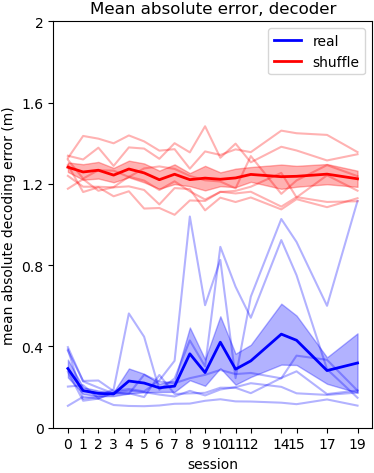

day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,0.3965,0.2279,0.1972,0.1691,0.1697,0.1508,0.2596,0.1662,0.1689,0.1717,0.1969,0.1965,0.1700,0.2450,0.2776,0.1655,0.1835
51004,0.3797,0.2303,0.2324,0.1801,0.1907,0.1789,0.2329,0.3296,1.0394,0.6029,0.8258,0.2442,0.6450,1.0272,0.9142,0.6000,1.1162
51007,0.2754,0.1328,0.1432,0.1726,0.1825,0.1755,0.1629,0.1538,0.1816,0.1590,0.1881,0.1998,0.2191,0.2012,0.1693,0.1614,0.1731
63,0.3854,0.1422,0.1537,0.1886,0.5624,0.4478,0.1870,0.2421,0.4296,0.3020,0.8902,0.6938,0.5412,0.9235,0.7505,0.2879,0.1475
64,0.1078,0.1522,0.1430,0.1118,0.1071,0.1059,0.1094,0.1178,0.1188,0.1325,0.1401,0.1296,0.1289,0.1232,0.1159,0.1391,0.1088
65,0.2025,0.2092,0.1449,0.1732,0.1666,0.2605,0.2266,0.2190,0.2437,0.2603,0.2843,0.2640,0.2695,0.2431,0.3547,0.3340,0.1825


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,1.1762,1.2234,1.1661,1.1839,1.2358,1.2164,1.1698,1.2127,1.1633,1.1233,1.1599,1.1657,1.1861,1.2541,1.1335,1.2423,1.1665
51004,1.2931,1.1599,1.1833,1.1390,1.1637,1.0786,1.0814,1.0479,1.1185,1.1159,1.1615,1.1530,1.1613,1.0882,1.1349,1.1111,1.1147
51007,1.2396,1.1861,1.1859,1.1830,1.1879,1.1701,1.0990,1.1794,1.1745,1.0698,1.1321,1.1108,1.1331,1.0745,1.1249,1.0854,1.1295
63,1.3189,1.2264,1.2672,1.2651,1.2341,1.2762,1.2860,1.2738,1.2391,1.2177,1.2118,1.1782,1.3368,1.1509,1.2170,1.2924,1.2379
64,1.3386,1.3202,1.3781,1.2885,1.3795,1.3738,1.3235,1.4002,1.3551,1.4836,1.3285,1.3981,1.3062,1.3827,1.3644,1.3153,1.3459
65,1.3269,1.4359,1.4226,1.3998,1.4385,1.4092,1.3636,1.3708,1.2749,1.3598,1.3424,1.3700,1.3562,1.4621,1.4493,1.4411,1.3563


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.364435,16,80,0.022777,1.584021,0.092480,0.252169,0.061474,0.126523
1,condition,46.984878,1,5,46.984878,108.351179,0.000141,0.000141,0.894121,1.000000
2,time * condition,0.507149,16,80,0.031697,1.953440,0.026858,0.189486,0.083537,0.130836


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d0,real,shuffle,t-test,-15.0541,2.3427e-05,0.0004,***,-6.1458,Cohen's d,0.2912,1.2822,-0.9910,0.1612,6,True,0.7650
1,d1,real,shuffle,t-test,-24.1273,2.2793e-06,3.8748e-05,***,-9.8499,Cohen's d,0.1825,1.2587,-1.0762,0.1093,6,True,0.9653
2,d2,real,shuffle,t-test,-19.7520,6.1431e-06,0.0001,***,-8.0637,Cohen's d,0.1691,1.2672,-1.0982,0.1362,6,True,0.4641
3,d3,real,shuffle,t-test,-25.2583,1.8156e-06,3.0865e-05,***,-10.3117,Cohen's d,0.1659,1.2432,-1.0773,0.1045,6,True,0.5165
4,d4,real,shuffle,t-test,-11.4363,8.9526e-05,0.0015,**,-4.6688,Cohen's d,0.2298,1.2733,-1.0434,0.2235,6,True,0.4067
5,d5,real,shuffle,t-test,-15.6668,1.9259e-05,0.0003,***,-6.3960,Cohen's d,0.2199,1.2541,-1.0342,0.1617,6,True,0.9717
6,d6,real,shuffle,t-test,-17.2274,1.2068e-05,0.0002,***,-7.0331,Cohen's d,0.1964,1.2205,-1.0241,0.1456,6,True,0.5411
7,d7,real,shuffle,t-test,-13.6496,3.7849e-05,0.0006,***,-5.5724,Cohen's d,0.2048,1.2475,-1.0427,0.1871,6,True,0.4470
8,d8,real,shuffle,t-test,-5.1879,0.0035,0.0595,,-2.1180,Cohen's d,0.3637,1.2209,-0.8572,0.4047,6,True,0.0519
9,d9,real,shuffle,t-test,-8.5406,0.0004,0.0062,**,-3.4867,Cohen's d,0.2714,1.2283,-0.9570,0.2745,6,True,0.6596


C:\Users\oles\AppData\Local\Temp\ipykernel_26268\4008648834.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


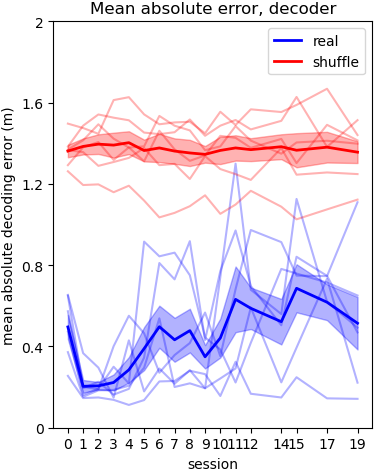

day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,0.6537,0.3669,0.2957,0.1484,0.4300,0.1787,0.2913,0.2166,0.2832,0.1938,0.7417,1.2995,0.6790,0.5595,1.1260,0.6202,0.4923
51004,0.5732,0.1950,0.2262,0.1628,0.1912,0.3452,0.8105,0.7301,0.9181,0.4317,0.7711,0.9707,0.6973,0.5043,0.8413,0.7474,0.4689
51007,0.3720,0.1522,0.1840,0.1862,0.2068,0.2949,0.5383,0.2004,0.2185,0.1944,0.2424,0.2916,0.5921,0.2233,0.3942,0.7333,0.2218
63,0.4721,0.1616,0.1925,0.3002,0.2180,0.9159,0.8435,0.8616,0.7505,0.4441,0.3850,0.2227,0.4178,0.7815,0.7588,0.7145,0.6508
64,0.2551,0.1460,0.1489,0.1371,0.1121,0.1361,0.2278,0.2301,0.2803,0.2638,0.1561,0.3245,0.1671,0.1488,0.2484,0.1446,0.1422
65,0.6495,0.2010,0.1895,0.4011,0.5510,0.4648,0.2708,0.3575,0.4167,0.5668,0.3526,0.6816,0.9731,0.9135,0.7486,0.7461,1.1095


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,1.2922,1.3799,1.4060,1.3179,1.3795,1.3111,1.4614,1.3699,1.3135,1.3402,1.4365,1.4266,1.3775,1.4212,1.3024,1.4906,1.4141
51004,1.2620,1.1944,1.1976,1.1589,1.1910,1.1179,1.0351,1.0573,1.0902,1.1438,1.0527,1.0983,1.1660,1.0878,1.0256,1.0744,1.1226
51007,1.3690,1.4144,1.4932,1.4226,1.3786,1.3848,1.5344,1.4863,1.4633,1.3659,1.3845,1.4844,1.4129,1.3485,1.4038,1.4123,1.3978
63,1.3660,1.3563,1.2888,1.3077,1.3279,1.3764,1.2921,1.2985,1.2242,1.3366,1.2729,1.2480,1.2196,1.3762,1.2453,1.2563,1.2483
64,1.3832,1.4865,1.5417,1.5259,1.5130,1.4525,1.4448,1.4543,1.5170,1.4368,1.4865,1.5145,1.4681,1.5102,1.6278,1.3820,1.5137
65,1.4966,1.4749,1.4465,1.6124,1.6267,1.5421,1.4934,1.5026,1.5058,1.4491,1.5549,1.4899,1.5669,1.5536,1.5885,1.6682,1.4403


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,1.008713,16,80,0.063045,2.596698,0.002682,0.090384,0.115038,0.188533
1,condition,43.890095,1,5,43.890095,76.784546,0.000321,0.000321,0.849761,1.000000
2,time * condition,1.194025,16,80,0.074627,3.157250,0.000346,0.049554,0.133353,0.204714


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d0,real,shuffle,t-test,-11.4944,8.7353e-05,0.0015,**,-4.6926,Cohen's d,0.4959,1.3615,-0.8656,0.1845,6,True,0.8655
1,d1,real,shuffle,t-test,-20.2384,5.4466e-06,9.2592e-05,***,-8.2623,Cohen's d,0.2038,1.3844,-1.1806,0.1429,6,True,0.2391
2,d2,real,shuffle,t-test,-18.5990,8.2698e-06,0.0001,***,-7.5930,Cohen's d,0.2061,1.3956,-1.1895,0.1567,6,True,0.8368
3,d3,real,shuffle,t-test,-19.2420,6.9915e-06,0.0001,***,-7.8555,Cohen's d,0.2226,1.3909,-1.1682,0.1487,6,True,0.5660
4,d4,real,shuffle,t-test,-17.1731,1.2258e-05,0.0002,***,-7.0109,Cohen's d,0.2849,1.4028,-1.1180,0.1595,6,True,0.4874
5,d5,real,shuffle,t-test,-7.7829,0.0006,0.0095,**,-3.1773,Cohen's d,0.3893,1.3641,-0.9749,0.3068,6,True,0.4008
6,d6,real,shuffle,t-test,-4.9593,0.0043,0.0723,,-2.0246,Cohen's d,0.4970,1.3769,-0.8798,0.4346,6,True,0.0674
7,d7,real,shuffle,wilcoxon,0.0000,0.0312,0.5312,,0.8987,r,0.4327,1.3615,-0.9288,0.4280,6,False,0.0291
8,d8,real,shuffle,t-test,-4.8071,0.0049,0.0825,,-1.9625,Cohen's d,0.4779,1.3523,-0.8744,0.4456,6,True,0.1130
9,d9,real,shuffle,t-test,-12.5514,5.6984e-05,0.0010,***,-5.1241,Cohen's d,0.3491,1.3454,-0.9963,0.1944,6,True,0.1475


C:\Users\oles\AppData\Local\Temp\ipykernel_26268\4008648834.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


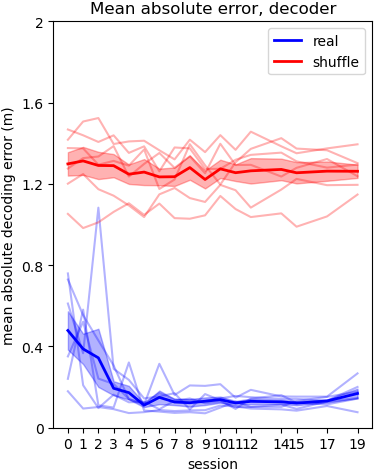

day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,0.6111,0.3667,1.0830,0.2898,0.2355,0.1442,0.1541,0.1699,0.0901,0.1657,0.1349,0.0924,0.1433,0.1604,0.1231,0.1148,0.1433
51004,0.3509,0.5214,0.2418,0.2153,0.1415,0.1129,0.3147,0.1612,0.2081,0.2059,0.2142,0.1478,0.1864,0.1541,0.1531,0.1530,0.2673
51007,0.2407,0.5812,0.1103,0.0993,0.3212,0.0846,0.0794,0.0730,0.0763,0.0710,0.0991,0.1287,0.1017,0.1137,0.0927,0.1293,0.1461
63,0.7593,0.2092,0.0965,0.1627,0.1252,0.1277,0.0910,0.1331,0.1438,0.1201,0.1276,0.1012,0.1032,0.1024,0.1316,0.1518,0.1775
64,0.1794,0.0943,0.1019,0.0914,0.0721,0.0766,0.0871,0.0821,0.0852,0.0864,0.1093,0.1049,0.0942,0.0904,0.0839,0.1069,0.0763
65,0.7292,0.5539,0.4294,0.3062,0.1401,0.1209,0.1700,0.1392,0.1344,0.1330,0.1444,0.1565,0.1502,0.1424,0.1417,0.1333,0.2007


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,1.4677,1.4392,1.4064,1.4389,1.3526,1.3848,1.2622,1.3793,1.3746,1.2736,1.2742,1.3188,1.3429,1.3538,1.3110,1.2799,1.2950
51004,1.2754,1.3269,1.3347,1.3860,1.2361,1.2982,1.3521,1.2787,1.3357,1.2523,1.3975,1.2927,1.2937,1.2361,1.2790,1.3225,1.2376
51007,1.4173,1.5070,1.5241,1.3962,1.4090,1.4124,1.3653,1.3207,1.4176,1.3563,1.4399,1.3677,1.4569,1.3850,1.3507,1.3746,1.3948
63,1.3763,1.3746,1.2944,1.3132,1.2898,1.3694,1.1749,1.2217,1.3952,1.2915,1.1968,1.3061,1.3724,1.4250,1.3738,1.3656,1.3022
64,1.2011,1.2484,1.1738,1.1420,1.0941,1.0368,1.1484,1.1798,1.1302,1.1111,1.1951,1.1688,1.0832,1.1721,1.2246,1.1937,1.1954
65,1.0524,0.9826,1.0107,1.0622,1.1048,1.0473,1.1030,1.0315,1.0285,1.0453,1.1406,1.0761,1.0367,1.0549,0.9893,1.0399,1.1476


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.773548,16,80,0.048347,5.009246,5.191858e-07,0.017521,0.194851,0.166947
1,condition,59.473771,1,5,59.473771,343.936904,8.388265e-06,0.000008,0.948997,1.000000
2,time * condition,0.419036,16,80,0.026190,3.137156,3.719020e-04,0.058752,0.115902,0.182399


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d0,real,shuffle,t-test,-6.5629,0.0012,0.0209,*,-2.6793,Cohen's d,0.4784,1.2984,-0.8199,0.3060,6,True,0.7734
1,d1,real,shuffle,t-test,-8.0885,0.0005,0.0080,**,-3.3021,Cohen's d,0.3878,1.3131,-0.9253,0.2802,6,True,0.2267
2,d2,real,shuffle,t-test,-5.6575,0.0024,0.0408,*,-2.3097,Cohen's d,0.3438,1.2907,-0.9468,0.4099,6,True,0.4579
3,d3,real,shuffle,t-test,-14.5790,2.7417e-05,0.0005,***,-5.9519,Cohen's d,0.1941,1.2897,-1.0956,0.1841,6,True,0.1885
4,d4,real,shuffle,t-test,-37.0031,2.7147e-07,4.6150e-06,***,-15.1065,Cohen's d,0.1726,1.2477,-1.0751,0.0712,6,True,0.8105
5,d5,real,shuffle,t-test,-17.0730,1.2616e-05,0.0002,***,-6.9700,Cohen's d,0.1112,1.2582,-1.1470,0.1646,6,True,0.2015
6,d6,real,shuffle,t-test,-22.9856,2.8991e-06,4.9284e-05,***,-9.3838,Cohen's d,0.1494,1.2343,-1.0849,0.1156,6,True,0.5477
7,d7,real,shuffle,t-test,-21.9027,3.6827e-06,6.2606e-05,***,-8.9417,Cohen's d,0.1264,1.2353,-1.1089,0.1240,6,True,0.4212
8,d8,real,shuffle,t-test,-16.8427,1.3489e-05,0.0002,***,-6.8760,Cohen's d,0.1230,1.2803,-1.1573,0.1683,6,True,0.6918
9,d9,real,shuffle,t-test,-20.7701,4.7905e-06,8.1438e-05,***,-8.4794,Cohen's d,0.1303,1.2217,-1.0913,0.1287,6,True,0.9907


C:\Users\oles\AppData\Local\Temp\ipykernel_26268\4008648834.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


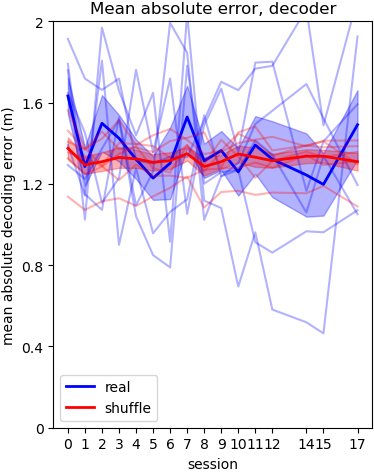

day,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19,d1
animal,,,,,,,,,,,,,,,,
170,1.3925,1.1425,1.8064,0.9001,1.2777,0.9570,1.0620,1.1245,1.5376,1.2375,1.2691,0.9128,0.8618,0.9667,0.9618,1.0704
51004,1.6468,1.4523,1.1063,1.2292,1.7617,1.3552,1.7191,1.0527,1.4893,1.6689,1.3567,1.7968,1.8016,1.1649,1.4092,1.5919
51007,1.7599,1.0244,1.9689,1.6581,1.4391,1.6482,0.9151,2.0383,1.1179,1.0813,0.6951,0.9617,0.5814,0.5188,0.4643,1.9258
63,1.2927,1.2237,1.3736,1.5150,1.0406,0.8494,0.7890,1.7816,1.2009,1.2576,1.2700,1.4143,1.3440,1.0590,1.3379,1.0509
64,1.9137,1.7183,1.6625,1.7180,1.3153,1.3008,1.3331,1.3316,1.5130,1.7025,1.6612,1.7670,1.7812,2.0607,1.4878,2.1133
65,1.7908,1.1499,1.0720,1.5274,1.0942,1.2613,1.9924,1.8457,1.0231,1.2372,1.3024,1.4944,1.5598,1.6915,1.5230,1.1943


day,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19,d1
animal,,,,,,,,,,,,,,,,
170,1.4620,1.3681,1.4576,1.3712,1.3794,1.3568,1.4109,1.4265,1.4535,1.2794,1.4539,1.4822,1.3646,1.3893,1.3799,1.3861
51004,1.3260,1.2477,1.2852,1.3475,1.3847,1.2768,1.2558,1.3909,1.2984,1.4170,1.3350,1.2296,1.3128,1.3584,1.3328,1.3572
51007,1.4072,1.3718,1.4225,1.5136,1.3913,1.4393,1.4704,1.4168,1.3463,1.3652,1.4474,1.4072,1.3378,1.3892,1.4090,1.2971
63,1.5628,1.3769,1.2892,1.4007,1.3966,1.3860,1.3288,1.3906,1.2615,1.3571,1.4014,1.4171,1.4317,1.3847,1.4128,1.4137
64,1.3553,1.3265,1.2872,1.2189,1.2948,1.2389,1.2409,1.2295,1.2701,1.2756,1.2795,1.3050,1.2798,1.3422,1.2932,1.3123
65,1.1372,1.0721,1.1142,1.1294,1.0918,1.1385,1.1810,1.2360,1.0835,1.1602,1.1658,1.1458,1.1574,1.1538,1.1901,1.0888


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.798356,15,75,0.053224,0.892100,0.575512,0.471126,0.062331,0.210048
1,condition,0.075388,1,5,0.075388,0.139897,0.723720,0.723720,0.006238,1.000000
2,time * condition,0.602952,15,75,0.040197,0.763052,0.712841,0.530979,0.047804,0.197591


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d2,real,shuffle,t-test,1.7561,0.1394,1.0000,,0.7169,Cohen's d,1.6327,1.3751,0.2577,0.3594,6,True,0.5441
1,d3,real,shuffle,t-test,-0.0755,0.9428,1.0000,,-0.0308,Cohen's d,1.2852,1.2939,-0.0087,0.2814,6,True,0.8162
2,d4,real,shuffle,t-test,1.6619,0.1574,1.0000,,0.6785,Cohen's d,1.4983,1.3093,0.1890,0.2785,6,True,0.7393
3,d5,real,shuffle,t-test,0.6546,0.5416,1.0000,,0.2672,Cohen's d,1.4246,1.3302,0.0944,0.3533,6,True,0.7711
4,d6,real,shuffle,t-test,-0.0170,0.9871,1.0000,,-0.0069,Cohen's d,1.3214,1.3231,-0.0016,0.2375,6,True,0.6622
5,d7,real,shuffle,t-test,-0.6117,0.5675,1.0000,,-0.2497,Cohen's d,1.2286,1.3061,-0.0774,0.3100,6,True,0.0873
6,d8,real,shuffle,t-test,-0.0557,0.9578,1.0000,,-0.0227,Cohen's d,1.3018,1.3147,-0.0129,0.5660,6,True,0.3610
7,d9,real,shuffle,t-test,1.0257,0.3521,1.0000,,0.4187,Cohen's d,1.5291,1.3484,0.1807,0.4315,6,True,0.2149
8,d10,real,shuffle,t-test,0.3881,0.7139,1.0000,,0.1584,Cohen's d,1.3136,1.2855,0.0281,0.1774,6,True,0.7341
9,d11,real,shuffle,t-test,0.5288,0.6196,1.0000,,0.2159,Cohen's d,1.3642,1.3091,0.0551,0.2552,6,True,0.9706


C:\Users\oles\AppData\Local\Temp\ipykernel_26268\4008648834.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


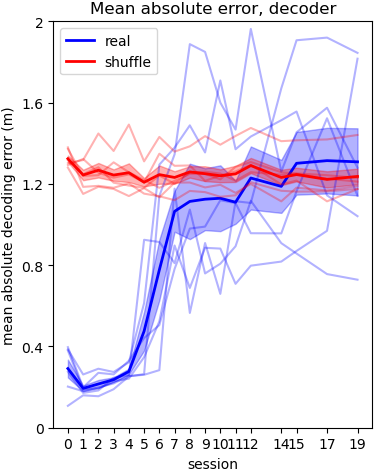

day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,0.3965,0.1987,0.2701,0.2625,0.3294,0.4415,0.5053,0.7817,0.9801,0.9898,1.1196,1.1055,0.9572,0.9564,1.1638,1.5230,1.1411
51004,0.3797,0.1902,0.1939,0.2279,0.2415,0.3472,0.5234,0.8968,0.6878,0.8854,0.8816,0.7081,0.7975,0.8177,0.8700,0.9691,1.8162
51007,0.2754,0.1713,0.1834,0.2461,0.2591,0.9249,0.9139,0.8099,1.0737,0.7593,0.8072,0.8931,1.1170,0.9083,0.8573,0.7561,0.7285
63,0.3854,0.2620,0.2904,0.2743,0.3218,0.6136,1.2947,1.3784,1.4881,1.3547,1.7091,1.3705,1.4330,1.5133,1.5561,1.1435,1.0410
64,0.1078,0.1595,0.1549,0.1894,0.2525,0.2639,1.1407,1.3457,1.8877,1.8496,1.6000,1.4672,1.9628,1.2606,1.4538,1.5747,1.2795
65,0.2025,0.1795,0.1987,0.2180,0.2542,0.2605,0.2833,1.1767,0.5650,0.9089,0.6587,1.1146,1.1062,1.6702,1.9069,1.9199,1.8447


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,,
170,1.2802,1.1507,1.1858,1.1751,1.1401,1.1791,1.1337,1.2061,1.2068,1.1826,1.1955,1.1558,1.1996,1.1142,1.1813,1.1678,1.1892
51004,1.3799,1.1853,1.1904,1.1809,1.2027,1.1520,1.1391,1.1199,1.1653,1.1595,1.1365,1.1438,1.2083,1.1660,1.1621,1.1632,1.1755
51007,1.3169,1.2476,1.2816,1.2060,1.1917,1.1805,1.2409,1.2012,1.2562,1.2598,1.2508,1.2154,1.2577,1.2451,1.2494,1.2261,1.2110
63,1.3721,1.2392,1.2430,1.3061,1.2572,1.2187,1.1806,1.2151,1.2496,1.2494,1.2226,1.2838,1.3074,1.2574,1.2516,1.2426,1.2295
64,1.2923,1.3228,1.2548,1.2306,1.2465,1.2071,1.3485,1.2890,1.2908,1.2147,1.2412,1.2612,1.2933,1.1972,1.2164,1.1141,1.1743
65,1.3018,1.3174,1.4479,1.3620,1.4919,1.3109,1.4312,1.3588,1.3849,1.4351,1.3928,1.4360,1.4752,1.4101,1.4146,1.4187,1.4408


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,9.411277,16,80,0.588205,12.737571,6.679506e-16,0.000421,0.484704,0.167105
1,condition,8.391052,1,5,8.391052,38.197429,1.616269e-03,0.001616,0.456127,1.000000
2,time * condition,9.979825,16,80,0.623739,14.611696,1.541565e-17,0.000127,0.499364,0.181391


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d0,real,shuffle,t-test,-24.5802,2.0783e-06,3.5331e-05,***,-10.0348,Cohen's d,0.2912,1.3239,-1.0326,0.1029,6,True,0.9831
1,d1,real,shuffle,t-test,-29.0693,9.0290e-07,1.5349e-05,***,-11.8675,Cohen's d,0.1935,1.2438,-1.0503,0.0885,6,True,0.3961
2,d2,real,shuffle,t-test,-21.0601,4.4726e-06,7.6035e-05,***,-8.5978,Cohen's d,0.2152,1.2673,-1.0520,0.1224,6,True,0.6301
3,d3,real,shuffle,t-test,-29.6614,8.1672e-07,1.3884e-05,***,-12.1092,Cohen's d,0.2364,1.2434,-1.0071,0.0832,6,True,0.6208
4,d4,real,shuffle,t-test,-16.9641,1.3020e-05,0.0002,***,-6.9256,Cohen's d,0.2764,1.2550,-0.9786,0.1413,6,True,0.2112
5,d5,real,shuffle,t-test,-6.3920,0.0014,0.0236,*,-2.6095,Cohen's d,0.4753,1.2081,-0.7328,0.2808,6,True,0.7345
6,d6,real,shuffle,t-test,-2.6538,0.0452,0.7687,,-1.0834,Cohen's d,0.7769,1.2457,-0.4688,0.4327,6,True,0.9188
7,d7,real,shuffle,t-test,-1.7297,0.1442,1.0000,,-0.7061,Cohen's d,1.0649,1.2317,-0.1668,0.2362,6,True,0.5196
8,d8,real,shuffle,t-test,-0.7051,0.5122,1.0000,,-0.2879,Cohen's d,1.1138,1.2589,-0.1452,0.5043,6,True,0.9474
9,d9,real,shuffle,t-test,-0.7023,0.5138,1.0000,,-0.2867,Cohen's d,1.1246,1.2502,-0.1256,0.4380,6,True,0.3161


In [13]:

def analyze_mae_config(results, config):
    animals = list(results[config].keys())
    num_animals = len(animals)
    
    if config == 'config_4':
        num_days = len(results[config][animals[0]]['scores_new_list'])
        mae_array = np.zeros((num_days, num_animals))  # Now correctly starting at day 1
        mae_array_shuff = np.zeros((num_days, num_animals))
    else:
        num_days = len(results[config][animals[0]]['scores_new_list']) + 1
        mae_array = np.zeros((num_days, num_animals))
        mae_array_shuff = np.zeros((num_days, num_animals))
    
    for i, animal in enumerate(animals):
        if config != 'config_4':
            mae_array[0, i] = results[config][animal]['scores_test']['mae']
            mae_array_shuff[0, i] = results[config][animal]['scores_test_shuff']['mae']
            
            for day in range(1, num_days):
                mae_array[day, i] = results[config][animal]['scores_new_list'][day-1]['mae']
                mae_array_shuff[day, i] = results[config][animal]['scores_new_list_shuff'][day-1]['mae']
        else:
            for day in range(num_days):
                mae_array[day-1, i] = results[config][animal]['scores_new_list'][day]['mae']
                mae_array_shuff[day-1, i] = results[config][animal]['scores_new_list_shuff'][day]['mae']
    
    return mae_array / 5, mae_array_shuff / 5


mae_day_labels = {
    'config_1': st.day_labels(days1),
    'config_2': st.day_labels(days1),
    'config_3': st.day_labels(days1),
    'config_4': st.day_labels(maps[1:] + maps[:1]),
    'config_5': st.day_labels(days1),
}


def plot_mae_configs_individual(results, configs, days1, days2):
    for i, config in enumerate(configs):
        mae_array, mae_array_shuff = analyze_mae_config(results, config)
        animals = list(results[config].keys())
        
        print_large('\n' + '=' * 50)
        print_large(titles[i])  
        print_large('\n' + '=' * 50)

        fig, ax = plt.subplots(figsize=(4, 5))


        days = days1[:mae_array.shape[0]]  

        mae_array = mae_array[::-1] if i == 2 else mae_array
        mae_array_shuff = mae_array_shuff[::-1] if i == 2 else mae_array_shuff

        plots.plot_average_geometry(
            [mae_array.T, mae_array_shuff.T],
            days,
            ax=ax,
            colors=['b', 'r'],
            ylim=[0, 2],
            ylabel='mean absolute decoding error (m)',
            labels=['real', 'shuffle']
        )
        ax.set_yticks([0, 0.4, 0.8, 1.2, 1.6, 2])
        ax.set_yticklabels(['0', '0.4', '0.8', '1.2', '1.6', '2'])

        plt.title(f'Mean absolute error, decoder')
        plt.tight_layout()
        plt.show()

        stat1 = st.repeated_measures_anova_general(
            [mae_array.T, mae_array_shuff.T],
            row_labels=animals, col_labels=mae_day_labels[config],
            condition_labels=['real', 'shuffle'],
            title=f'Decoder MAE (m), {titles[i]}: real vs shuffle')
        display(stat1[0])
        display(stat1[1])

configs = ['config_1', 'config_2', 'config_3', 'config_4', 'config_5']
titles = ['fam aligned to fam d0', 'nov aligned to nov d0', 'nov aligned to nov d19', 'nov aligned to fam d19', 'sim fam aligned to sim fam d0']
plot_mae_configs_individual(results, configs, days1, days2)



C:\Users\oles\AppData\Local\Temp\ipykernel_26268\950516096.py:82: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


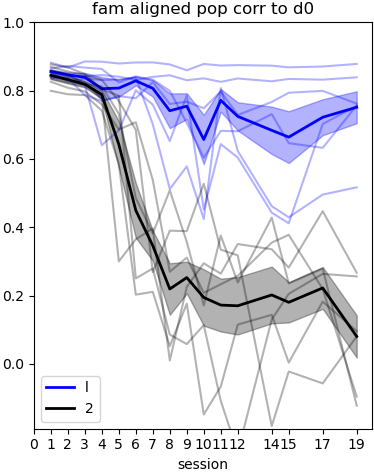

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.8571,0.8440,0.8421,0.8455,0.8408,0.8314,0.8403,0.8450,0.8304,0.8360,0.8257,0.8356,0.8273,0.8342,0.8322,0.8390
51004,0.8525,0.8262,0.8353,0.8310,0.8324,0.8385,0.7016,0.5119,0.5780,0.4240,0.8073,0.6234,0.4617,0.4290,0.4956,0.5168
51007,0.8390,0.8364,0.7870,0.7693,0.7838,0.7777,0.8248,0.7610,0.7675,0.7484,0.7974,0.7287,0.7668,0.7938,0.7993,0.7620
63,0.8393,0.8321,0.8159,0.6403,0.6839,0.8011,0.7589,0.6521,0.7861,0.4515,0.6433,0.6041,0.4425,0.4116,0.7025,0.7552
64,0.8820,0.8674,0.8854,0.8848,0.8794,0.8825,0.8826,0.8767,0.8596,0.8782,0.8735,0.8747,0.8731,0.8683,0.8706,0.8782
65,0.8649,0.8723,0.8675,0.8636,0.8240,0.8415,0.8321,0.7995,0.7052,0.6035,0.6821,0.6810,0.7312,0.6462,0.6324,0.7567


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.8259,0.8084,0.7977,0.7595,0.6861,0.7074,0.5382,0.2697,0.3112,0.2077,0.2331,0.2576,0.3549,0.3776,0.2190,-0.0959
51004,0.8599,0.8478,0.8196,0.8125,0.7323,0.4852,0.3820,0.5081,0.3569,0.1713,0.3757,0.2382,0.4282,0.2355,0.2789,-0.1224
51007,0.8357,0.8240,0.8142,0.7819,0.3000,0.3647,0.3964,0.0095,0.2252,0.2944,0.2641,0.3508,0.3355,0.2818,0.4470,0.2667
63,0.7995,0.7894,0.7870,0.7414,0.5850,0.2026,0.2108,0.0519,0.1761,-0.1481,-0.0667,0.1148,0.1435,0.0035,0.1822,0.0958
64,0.8770,0.8684,0.8485,0.8040,0.7850,0.2503,0.2792,0.0858,0.0578,0.1134,-0.1083,-0.2592,0.1299,0.2050,0.2634,0.2560
65,0.8698,0.8559,0.8459,0.8315,0.7694,0.6852,0.2687,0.3900,0.3885,0.5274,0.3345,0.3175,-0.1821,-0.0225,-0.0573,0.0804


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,5.101147,15,75,0.340076,21.132743,5.132032e-21,0.000003,0.612748,0.232252
1,condition,6.405289,1,5,6.405289,67.875448,4.293389e-04,0.000429,0.665196,1.000000
2,time * condition,2.464415,15,75,0.164294,11.740018,3.768710e-14,0.000099,0.433242,0.239990


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1,fam vs fam d0,sim fam vs sim fam d0,t-test,1.3905,0.2231,1.0000,,0.5677,Cohen's d,0.8558,0.8446,0.0111,0.0196,6,True,0.1826
1,d2,fam vs fam d0,sim fam vs sim fam d0,t-test,1.4622,0.2036,1.0000,,0.5969,Cohen's d,0.8464,0.8323,0.0141,0.0236,6,True,0.8744
2,d3,fam vs fam d0,sim fam vs sim fam d0,t-test,1.9370,0.1105,1.0000,,0.7908,Cohen's d,0.8389,0.8188,0.0200,0.0253,6,True,0.2012
3,d4,fam vs fam d0,sim fam vs sim fam d0,t-test,0.6120,0.5673,1.0000,,0.2498,Cohen's d,0.8057,0.7885,0.0173,0.0691,6,True,0.4614
4,d5,fam vs fam d0,sim fam vs sim fam d0,wilcoxon,0.0000,0.0312,0.5000,,0.8987,r,0.8074,0.6430,0.1644,0.1597,6,False,0.0032
5,d6,fam vs fam d0,sim fam vs sim fam d0,t-test,4.3471,0.0074,0.1181,,1.7747,Cohen's d,0.8288,0.4492,0.3796,0.2139,6,True,0.4341
6,d7,fam vs fam d0,sim fam vs sim fam d0,t-test,8.6756,0.0003,0.0054,**,3.5418,Cohen's d,0.8067,0.3459,0.4608,0.1301,6,True,0.2634
7,d8,fam vs fam d0,sim fam vs sim fam d0,t-test,4.4372,0.0068,0.1085,,1.8115,Cohen's d,0.7410,0.2192,0.5219,0.2881,6,True,0.2674
8,d9,fam vs fam d0,sim fam vs sim fam d0,t-test,5.9055,0.0020,0.0317,*,2.4109,Cohen's d,0.7545,0.2526,0.5019,0.2082,6,True,0.8710
9,d10,fam vs fam d0,sim fam vs sim fam d0,t-test,4.4037,0.0070,0.1120,,1.7978,Cohen's d,0.6569,0.1944,0.4626,0.2573,6,True,0.7478


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.8571,0.8440,0.8421,0.8455,0.8408,0.8314,0.8403,0.8450,0.8304,0.8360,0.8257,0.8356,0.8273,0.8342,0.8322,0.8390
51004,0.8525,0.8262,0.8353,0.8310,0.8324,0.8385,0.7016,0.5119,0.5780,0.4240,0.8073,0.6234,0.4617,0.4290,0.4956,0.5168
51007,0.8390,0.8364,0.7870,0.7693,0.7838,0.7777,0.8248,0.7610,0.7675,0.7484,0.7974,0.7287,0.7668,0.7938,0.7993,0.7620
63,0.8393,0.8321,0.8159,0.6403,0.6839,0.8011,0.7589,0.6521,0.7861,0.4515,0.6433,0.6041,0.4425,0.4116,0.7025,0.7552
64,0.8820,0.8674,0.8854,0.8848,0.8794,0.8825,0.8826,0.8767,0.8596,0.8782,0.8735,0.8747,0.8731,0.8683,0.8706,0.8782
65,0.8649,0.8723,0.8675,0.8636,0.8240,0.8415,0.8321,0.7995,0.7052,0.6035,0.6821,0.6810,0.7312,0.6462,0.6324,0.7567


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.374740,15,0.024983,3.711187,0.000076,0.255112,0.127817
1,Error,0.504879,75,0.006732,NaN,NaN,NaN,NaN


C:\Users\oles\AppData\Local\Temp\ipykernel_26268\950516096.py:82: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


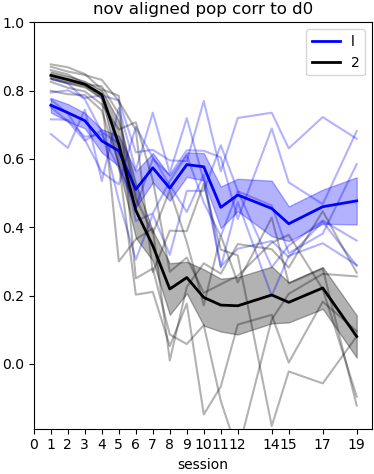

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.6729,0.6321,0.7445,0.5352,0.7495,0.5676,0.7355,0.5594,0.7196,0.5361,0.2820,0.4737,0.1990,0.3162,0.3530,0.2896
51004,0.8352,0.8210,0.7745,0.6784,0.6453,0.4183,0.4403,0.5352,0.6104,0.4719,0.3739,0.5052,0.4637,0.3241,0.3812,0.5848
51007,0.7159,0.7150,0.6648,0.6723,0.5729,0.4595,0.5996,0.5529,0.6253,0.6238,0.6048,0.4240,0.6891,0.5313,0.4676,0.6816
63,0.7514,0.7100,0.6538,0.6840,0.4770,0.3053,0.4377,0.3193,0.5065,0.5065,0.6401,0.5069,0.2827,0.3462,0.4196,0.3609
64,0.7943,0.8008,0.7786,0.7861,0.7712,0.6195,0.6268,0.5957,0.5935,0.7696,0.5635,0.7200,0.7354,0.6308,0.7225,0.6590
65,0.7738,0.7332,0.6561,0.5609,0.5255,0.6938,0.6043,0.5233,0.4448,0.5545,0.2853,0.3371,0.3598,0.3125,0.4164,0.2872


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.8259,0.8084,0.7977,0.7595,0.6861,0.7074,0.5382,0.2697,0.3112,0.2077,0.2331,0.2576,0.3549,0.3776,0.2190,-0.0959
51004,0.8599,0.8478,0.8196,0.8125,0.7323,0.4852,0.3820,0.5081,0.3569,0.1713,0.3757,0.2382,0.4282,0.2355,0.2789,-0.1224
51007,0.8357,0.8240,0.8142,0.7819,0.3000,0.3647,0.3964,0.0095,0.2252,0.2944,0.2641,0.3508,0.3355,0.2818,0.4470,0.2667
63,0.7995,0.7894,0.7870,0.7414,0.5850,0.2026,0.2108,0.0519,0.1761,-0.1481,-0.0667,0.1148,0.1435,0.0035,0.1822,0.0958
64,0.8770,0.8684,0.8485,0.8040,0.7850,0.2503,0.2792,0.0858,0.0578,0.1134,-0.1083,-0.2592,0.1299,0.2050,0.2634,0.2560
65,0.8698,0.8559,0.8459,0.8315,0.7694,0.6852,0.2687,0.3900,0.3885,0.5274,0.3345,0.3175,-0.1821,-0.0225,-0.0573,0.0804


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,6.601533,15,75,0.440102,22.520754,7.940619e-22,0.000010,0.658068,0.195604
1,condition,1.249106,1,5,1.249106,12.707857,1.613215e-02,0.016132,0.266946,1.000000
2,time * condition,1.644544,15,75,0.109636,7.373223,1.144910e-09,0.001445,0.324068,0.236266


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1,nov vs nov d0,sim fam vs sim fam d0,t-test,-4.5813,0.0059,0.0950,,-1.8703,Cohen's d,0.7573,0.8446,-0.0874,0.0467,6,True,0.9777
1,d2,nov vs nov d0,sim fam vs sim fam d0,t-test,-4.6237,0.0057,0.0915,,-1.8876,Cohen's d,0.7353,0.8323,-0.0970,0.0514,6,True,0.9848
2,d3,nov vs nov d0,sim fam vs sim fam d0,t-test,-4.4310,0.0068,0.1092,,-1.8089,Cohen's d,0.7121,0.8188,-0.1068,0.0590,6,True,0.4020
3,d4,nov vs nov d0,sim fam vs sim fam d0,t-test,-3.4364,0.0185,0.2961,,-1.4029,Cohen's d,0.6528,0.7885,-0.1356,0.0967,6,True,0.7977
4,d5,nov vs nov d0,sim fam vs sim fam d0,t-test,-0.2699,0.7980,1.0000,,-0.1102,Cohen's d,0.6236,0.6430,-0.0194,0.1761,6,True,0.8545
5,d6,nov vs nov d0,sim fam vs sim fam d0,t-test,0.8486,0.4348,1.0000,,0.3464,Cohen's d,0.5107,0.4492,0.0614,0.1774,6,True,0.5808
6,d7,nov vs nov d0,sim fam vs sim fam d0,t-test,5.2717,0.0033,0.0523,,2.1522,Cohen's d,0.5740,0.3459,0.2282,0.1060,6,True,0.4755
7,d8,nov vs nov d0,sim fam vs sim fam d0,t-test,3.5566,0.0163,0.2604,,1.4520,Cohen's d,0.5143,0.2192,0.2951,0.2033,6,True,0.6240
8,d9,nov vs nov d0,sim fam vs sim fam d0,t-test,4.9465,0.0043,0.0688,,2.0194,Cohen's d,0.5833,0.2526,0.3307,0.1638,6,True,0.7784
9,d10,nov vs nov d0,sim fam vs sim fam d0,t-test,3.9084,0.0113,0.1810,,1.5956,Cohen's d,0.5771,0.1944,0.3827,0.2399,6,True,0.2819


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.6729,0.6321,0.7445,0.5352,0.7495,0.5676,0.7355,0.5594,0.7196,0.5361,0.2820,0.4737,0.1990,0.3162,0.3530,0.2896
51004,0.8352,0.8210,0.7745,0.6784,0.6453,0.4183,0.4403,0.5352,0.6104,0.4719,0.3739,0.5052,0.4637,0.3241,0.3812,0.5848
51007,0.7159,0.7150,0.6648,0.6723,0.5729,0.4595,0.5996,0.5529,0.6253,0.6238,0.6048,0.4240,0.6891,0.5313,0.4676,0.6816
63,0.7514,0.7100,0.6538,0.6840,0.4770,0.3053,0.4377,0.3193,0.5065,0.5065,0.6401,0.5069,0.2827,0.3462,0.4196,0.3609
64,0.7943,0.8008,0.7786,0.7861,0.7712,0.6195,0.6268,0.5957,0.5935,0.7696,0.5635,0.7200,0.7354,0.6308,0.7225,0.6590
65,0.7738,0.7332,0.6561,0.5609,0.5255,0.6938,0.6043,0.5233,0.4448,0.5545,0.2853,0.3371,0.3598,0.3125,0.4164,0.2872


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,1.055255,15,0.070350,6.362788,1.901787e-08,0.447959,0.217167
1,Error,0.829240,75,0.011057,NaN,NaN,NaN,NaN


C:\Users\oles\AppData\Local\Temp\ipykernel_26268\950516096.py:82: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


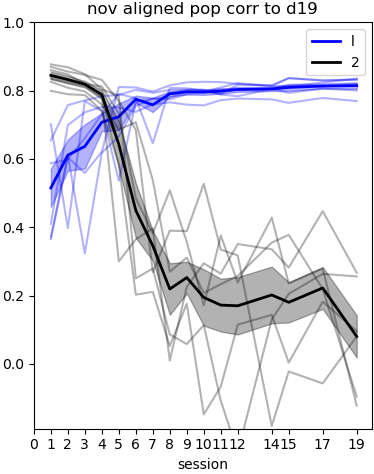

day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17
animal,,,,,,,,,,,,,,,,
170,0.3706,0.6102,0.3233,0.6180,0.6661,0.7553,0.7762,0.7743,0.7899,0.7967,0.8095,0.8221,0.8135,0.8124,0.8237,0.8353
51004,0.5875,0.5984,0.6606,0.7306,0.7904,0.7778,0.6457,0.8077,0.8068,0.7997,0.7895,0.8170,0.8164,0.8366,0.8301,0.8315
51007,0.7016,0.3976,0.7694,0.7399,0.5359,0.7678,0.7766,0.7795,0.7970,0.7942,0.8050,0.8015,0.8068,0.8137,0.8131,0.8186
63,0.4100,0.6990,0.7368,0.7521,0.7508,0.7377,0.7603,0.7657,0.7590,0.7568,0.7721,0.7767,0.7744,0.7643,0.7785,0.7695
64,0.6545,0.7575,0.7715,0.7833,0.7875,0.8023,0.7936,0.8018,0.8028,0.8028,0.7885,0.7837,0.8049,0.7934,0.8059,0.8004
65,0.3658,0.6045,0.5589,0.6209,0.8107,0.8092,0.7973,0.8153,0.8243,0.8258,0.8251,0.8198,0.8129,0.8366,0.8296,0.8332


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.8259,0.8084,0.7977,0.7595,0.6861,0.7074,0.5382,0.2697,0.3112,0.2077,0.2331,0.2576,0.3549,0.3776,0.2190,-0.0959
51004,0.8599,0.8478,0.8196,0.8125,0.7323,0.4852,0.3820,0.5081,0.3569,0.1713,0.3757,0.2382,0.4282,0.2355,0.2789,-0.1224
51007,0.8357,0.8240,0.8142,0.7819,0.3000,0.3647,0.3964,0.0095,0.2252,0.2944,0.2641,0.3508,0.3355,0.2818,0.4470,0.2667
63,0.7995,0.7894,0.7870,0.7414,0.5850,0.2026,0.2108,0.0519,0.1761,-0.1481,-0.0667,0.1148,0.1435,0.0035,0.1822,0.0958
64,0.8770,0.8684,0.8485,0.8040,0.7850,0.2503,0.2792,0.0858,0.0578,0.1134,-0.1083,-0.2592,0.1299,0.2050,0.2634,0.2560
65,0.8698,0.8559,0.8459,0.8315,0.7694,0.6852,0.2687,0.3900,0.3885,0.5274,0.3345,0.3175,-0.1821,-0.0225,-0.0573,0.0804


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,1.922274,15,75,0.128152,7.492789,8.309193e-10,1.545675e-03,0.426027,0.228651
1,condition,5.755490,1,5,5.755490,118.030899,1.147303e-04,1.147303e-04,0.689668,1.000000
2,time * condition,5.966342,15,75,0.397756,33.736218,3.184683e-27,1.457703e-07,0.697316,0.225215


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d0 | d1,nov vs nov d19,sim fam vs sim fam d0,t-test,-5.6326,0.0024,0.0391,*,-2.2995,Cohen's d,0.5150,0.8446,-0.3296,0.1434,6,True,0.7926
1,d1 | d2,nov vs nov d19,sim fam vs sim fam d0,t-test,-4.4632,0.0066,0.1059,,-1.8221,Cohen's d,0.6112,0.8323,-0.2211,0.1213,6,True,0.4919
2,d2 | d3,nov vs nov d19,sim fam vs sim fam d0,t-test,-2.6256,0.0468,0.7485,,-1.0719,Cohen's d,0.6368,0.8188,-0.1821,0.1699,6,True,0.1540
3,d3 | d4,nov vs nov d19,sim fam vs sim fam d0,t-test,-2.4053,0.0612,0.9795,,-0.9820,Cohen's d,0.7075,0.7885,-0.0810,0.0825,6,True,0.7356
4,d4 | d5,nov vs nov d19,sim fam vs sim fam d0,t-test,1.9815,0.1044,1.0000,,0.8089,Cohen's d,0.7236,0.6430,0.0806,0.0996,6,True,0.3983
5,d5 | d6,nov vs nov d19,sim fam vs sim fam d0,t-test,3.8042,0.0126,0.2012,,1.5531,Cohen's d,0.7750,0.4492,0.3258,0.2098,6,True,0.4871
6,d6 | d7,nov vs nov d19,sim fam vs sim fam d0,t-test,7.2813,0.0008,0.0122,*,2.9726,Cohen's d,0.7583,0.3459,0.4124,0.1387,6,True,0.1651
7,d7 | d8,nov vs nov d19,sim fam vs sim fam d0,t-test,7.3724,0.0007,0.0115,*,3.0098,Cohen's d,0.7907,0.2192,0.5716,0.1899,6,True,0.3653
8,d8 | d9,nov vs nov d19,sim fam vs sim fam d0,t-test,11.4696,8.8273e-05,0.0014,**,4.6824,Cohen's d,0.7967,0.2526,0.5440,0.1162,6,True,0.2908
9,d9 | d10,nov vs nov d19,sim fam vs sim fam d0,t-test,7.3160,0.0007,0.0120,*,2.9867,Cohen's d,0.7960,0.1944,0.6016,0.2014,6,True,0.9672


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17
animal,,,,,,,,,,,,,,,,
170,0.3706,0.6102,0.3233,0.6180,0.6661,0.7553,0.7762,0.7743,0.7899,0.7967,0.8095,0.8221,0.8135,0.8124,0.8237,0.8353
51004,0.5875,0.5984,0.6606,0.7306,0.7904,0.7778,0.6457,0.8077,0.8068,0.7997,0.7895,0.8170,0.8164,0.8366,0.8301,0.8315
51007,0.7016,0.3976,0.7694,0.7399,0.5359,0.7678,0.7766,0.7795,0.7970,0.7942,0.8050,0.8015,0.8068,0.8137,0.8131,0.8186
63,0.4100,0.6990,0.7368,0.7521,0.7508,0.7377,0.7603,0.7657,0.7590,0.7568,0.7721,0.7767,0.7744,0.7643,0.7785,0.7695
64,0.6545,0.7575,0.7715,0.7833,0.7875,0.8023,0.7936,0.8018,0.8028,0.8028,0.7885,0.7837,0.8049,0.7934,0.8059,0.8004
65,0.3658,0.6045,0.5589,0.6209,0.8107,0.8092,0.7973,0.8153,0.8243,0.8258,0.8251,0.8198,0.8129,0.8366,0.8296,0.8332


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.697795,15,0.046520,8.399403,7.899315e-11,0.602637,0.162004
1,Error,0.415383,75,0.005538,NaN,NaN,NaN,NaN


C:\Users\oles\AppData\Local\Temp\ipykernel_26268\950516096.py:82: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


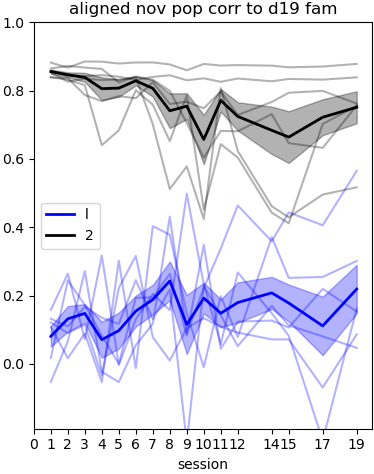

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.1079,0.0166,0.0889,-0.0534,0.3019,-0.0126,0.4032,0.3781,0.1478,-0.0100,0.1981,0.0787,0.3712,0.2518,0.2544,0.3013
51004,0.1584,0.2639,0.0718,0.3174,-0.0037,0.1306,0.2046,0.1572,0.4982,0.2325,0.0578,0.2678,0.1482,0.0823,-0.2242,0.1616
51007,-0.0528,0.0658,0.2716,-0.0232,-0.0534,0.0547,0.1171,0.4308,0.0887,0.2221,0.3379,0.4636,0.3589,0.4435,0.4058,0.5651
63,0.0170,0.2447,0.1723,0.0827,-0.0000,0.1932,0.1947,0.2635,0.0826,0.3483,0.0440,0.1236,0.1267,0.1066,0.2195,0.1530
64,0.1210,0.0901,0.1147,-0.0341,0.2221,0.3159,0.0782,0.0096,0.1050,0.1339,0.1086,0.0915,0.0715,0.0716,-0.0694,0.0863
65,0.1320,0.1096,0.1671,0.1348,0.1171,0.2451,0.1309,0.2176,-0.2316,0.2282,0.1421,0.0517,0.1698,0.1126,0.0803,0.0468


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.8571,0.8440,0.8421,0.8455,0.8408,0.8314,0.8403,0.8450,0.8304,0.8360,0.8257,0.8356,0.8273,0.8342,0.8322,0.8390
51004,0.8525,0.8262,0.8353,0.8310,0.8324,0.8385,0.7016,0.5119,0.5780,0.4240,0.8073,0.6234,0.4617,0.4290,0.4956,0.5168
51007,0.8390,0.8364,0.7870,0.7693,0.7838,0.7777,0.8248,0.7610,0.7675,0.7484,0.7974,0.7287,0.7668,0.7938,0.7993,0.7620
63,0.8393,0.8321,0.8159,0.6403,0.6839,0.8011,0.7589,0.6521,0.7861,0.4515,0.6433,0.6041,0.4425,0.4116,0.7025,0.7552
64,0.8820,0.8674,0.8854,0.8848,0.8794,0.8825,0.8826,0.8767,0.8596,0.8782,0.8735,0.8747,0.8731,0.8683,0.8706,0.8782
65,0.8649,0.8723,0.8675,0.8636,0.8240,0.8415,0.8321,0.7995,0.7052,0.6035,0.6821,0.6810,0.7312,0.6462,0.6324,0.7567


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.145965,15,75,0.009731,0.627654,0.843127,0.583268,0.049194,0.166447
1,condition,17.988114,1,5,17.988114,205.053836,0.000030,0.000030,0.864429,1.000000
2,time * condition,0.458824,15,75,0.030588,2.589397,0.003552,0.078013,0.139887,0.235420


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1,nov vs fam d19,fam vs fam d0,t-test,-26.8363,1.3435e-06,2.1497e-05,***,-10.9559,Cohen's d,0.0806,0.8558,-0.7752,0.0708,6,True,0.6357
1,d2,nov vs fam d19,fam vs fam d0,t-test,-15.7875,1.8546e-05,0.0003,***,-6.4452,Cohen's d,0.1318,0.8464,-0.7146,0.1109,6,True,0.0874
2,d3,nov vs fam d19,fam vs fam d0,t-test,-17.1656,1.2284e-05,0.0002,***,-7.0078,Cohen's d,0.1477,0.8389,-0.6911,0.0986,6,True,0.1370
3,d4,nov vs fam d19,fam vs fam d0,t-test,-10.5894,0.0001,0.0021,**,-4.3231,Cohen's d,0.0707,0.8057,-0.7350,0.1700,6,True,0.4166
4,d5,nov vs fam d19,fam vs fam d0,t-test,-15.2729,2.1825e-05,0.0003,***,-6.2351,Cohen's d,0.0973,0.8074,-0.7101,0.1139,6,True,0.4954
5,d6,nov vs fam d19,fam vs fam d0,t-test,-15.8351,1.8274e-05,0.0003,***,-6.4646,Cohen's d,0.1545,0.8288,-0.6743,0.1043,6,True,0.4526
6,d7,nov vs fam d19,fam vs fam d0,t-test,-10.7169,0.0001,0.0020,**,-4.3751,Cohen's d,0.1881,0.8067,-0.6186,0.1414,6,True,0.7022
7,d8,nov vs fam d19,fam vs fam d0,t-test,-6.0289,0.0018,0.0289,*,-2.4613,Cohen's d,0.2428,0.7410,-0.4982,0.2024,6,True,0.1411
8,d9,nov vs fam d19,fam vs fam d0,wilcoxon,0.0000,0.0312,0.5000,,0.8987,r,0.1151,0.7545,-0.6393,0.2906,6,False,0.0389
9,d10,nov vs fam d19,fam vs fam d0,t-test,-3.8324,0.0122,0.1955,,-1.5646,Cohen's d,0.1925,0.6569,-0.4644,0.2968,6,True,0.7185


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.1079,0.0166,0.0889,-0.0534,0.3019,-0.0126,0.4032,0.3781,0.1478,-0.0100,0.1981,0.0787,0.3712,0.2518,0.2544,0.3013
51004,0.1584,0.2639,0.0718,0.3174,-0.0037,0.1306,0.2046,0.1572,0.4982,0.2325,0.0578,0.2678,0.1482,0.0823,-0.2242,0.1616
51007,-0.0528,0.0658,0.2716,-0.0232,-0.0534,0.0547,0.1171,0.4308,0.0887,0.2221,0.3379,0.4636,0.3589,0.4435,0.4058,0.5651
63,0.0170,0.2447,0.1723,0.0827,-0.0000,0.1932,0.1947,0.2635,0.0826,0.3483,0.0440,0.1236,0.1267,0.1066,0.2195,0.1530
64,0.1210,0.0901,0.1147,-0.0341,0.2221,0.3159,0.0782,0.0096,0.1050,0.1339,0.1086,0.0915,0.0715,0.0716,-0.0694,0.0863
65,0.1320,0.1096,0.1671,0.1348,0.1171,0.2451,0.1309,0.2176,-0.2316,0.2282,0.1421,0.0517,0.1698,0.1126,0.0803,0.0468


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.230048,15,0.015337,0.745039,0.731482,0.117551,0.205434
1,Error,1.543866,75,0.020585,NaN,NaN,NaN,NaN


C:\Users\oles\AppData\Local\Temp\ipykernel_26268\950516096.py:82: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


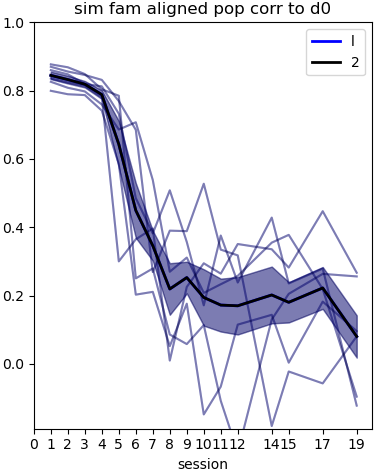

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.8259,0.8084,0.7977,0.7595,0.6861,0.7074,0.5382,0.2697,0.3112,0.2077,0.2331,0.2576,0.3549,0.3776,0.2190,-0.0959
51004,0.8599,0.8478,0.8196,0.8125,0.7323,0.4852,0.3820,0.5081,0.3569,0.1713,0.3757,0.2382,0.4282,0.2355,0.2789,-0.1224
51007,0.8357,0.8240,0.8142,0.7819,0.3000,0.3647,0.3964,0.0095,0.2252,0.2944,0.2641,0.3508,0.3355,0.2818,0.4470,0.2667
63,0.7995,0.7894,0.7870,0.7414,0.5850,0.2026,0.2108,0.0519,0.1761,-0.1481,-0.0667,0.1148,0.1435,0.0035,0.1822,0.0958
64,0.8770,0.8684,0.8485,0.8040,0.7850,0.2503,0.2792,0.0858,0.0578,0.1134,-0.1083,-0.2592,0.1299,0.2050,0.2634,0.2560
65,0.8698,0.8559,0.8459,0.8315,0.7694,0.6852,0.2687,0.3900,0.3885,0.5274,0.3345,0.3175,-0.1821,-0.0225,-0.0573,0.0804


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.8259,0.8084,0.7977,0.7595,0.6861,0.7074,0.5382,0.2697,0.3112,0.2077,0.2331,0.2576,0.3549,0.3776,0.2190,-0.0959
51004,0.8599,0.8478,0.8196,0.8125,0.7323,0.4852,0.3820,0.5081,0.3569,0.1713,0.3757,0.2382,0.4282,0.2355,0.2789,-0.1224
51007,0.8357,0.8240,0.8142,0.7819,0.3000,0.3647,0.3964,0.0095,0.2252,0.2944,0.2641,0.3508,0.3355,0.2818,0.4470,0.2667
63,0.7995,0.7894,0.7870,0.7414,0.5850,0.2026,0.2108,0.0519,0.1761,-0.1481,-0.0667,0.1148,0.1435,0.0035,0.1822,0.0958
64,0.8770,0.8684,0.8485,0.8040,0.7850,0.2503,0.2792,0.0858,0.0578,0.1134,-0.1083,-0.2592,0.1299,0.2050,0.2634,0.2560
65,0.8698,0.8559,0.8459,0.8315,0.7694,0.6852,0.2687,0.3900,0.3885,0.5274,0.3345,0.3175,-0.1821,-0.0225,-0.0573,0.0804


c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\pingouin\parametric.py:748: RuntimeWarning: invalid value encountered in scalar divide
  f_b = ms_b / ms_bs
c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\pingouin\distribution.py:743: RuntimeWarning: invalid value encountered in scalar divide
  eps = np.min([num / den, 1])
c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\scipy\stats\_morestats.py:1813: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "
c:\Users\oles\Documents\code\Sylte_Kilias_et_al\analysis_code\statistics_test.py:409: RuntimeWarning: invalid value encountered in scalar divide
  effect_size = np.mean(differences) / np.std(differences, ddof=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,14.381644,15,75,0.958776,20.526091,1.195152e-20,0.000005,0.771503,0.222597
1,condition,0.000000,1,5,0.000000,NaN,NaN,NaN,0.000000,1.000000
2,time * condition,0.000000,15,75,0.000000,0.000000,1.000000e+00,NaN,0.000000,NaN


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1,sim fam vs sim fam d0,sim fam vs sim fam d0,t-test,NaN,nan,nan,,NaN,Cohen's d,0.8446,0.8446,0.0,0.0,6,True,1.0000
1,d2,sim fam vs sim fam d0,sim fam vs sim fam d0,t-test,NaN,nan,nan,,NaN,Cohen's d,0.8323,0.8323,0.0,0.0,6,True,1.0000
2,d3,sim fam vs sim fam d0,sim fam vs sim fam d0,t-test,NaN,nan,nan,,NaN,Cohen's d,0.8188,0.8188,0.0,0.0,6,True,1.0000
3,d4,sim fam vs sim fam d0,sim fam vs sim fam d0,t-test,NaN,nan,nan,,NaN,Cohen's d,0.7885,0.7885,0.0,0.0,6,True,1.0000
4,d5,sim fam vs sim fam d0,sim fam vs sim fam d0,t-test,NaN,nan,nan,,NaN,Cohen's d,0.6430,0.6430,0.0,0.0,6,True,1.0000
5,d6,sim fam vs sim fam d0,sim fam vs sim fam d0,t-test,NaN,nan,nan,,NaN,Cohen's d,0.4492,0.4492,0.0,0.0,6,True,1.0000
6,d7,sim fam vs sim fam d0,sim fam vs sim fam d0,t-test,NaN,nan,nan,,NaN,Cohen's d,0.3459,0.3459,0.0,0.0,6,True,1.0000
7,d8,sim fam vs sim fam d0,sim fam vs sim fam d0,t-test,NaN,nan,nan,,NaN,Cohen's d,0.2192,0.2192,0.0,0.0,6,True,1.0000
8,d9,sim fam vs sim fam d0,sim fam vs sim fam d0,t-test,NaN,nan,nan,,NaN,Cohen's d,0.2526,0.2526,0.0,0.0,6,True,1.0000
9,d10,sim fam vs sim fam d0,sim fam vs sim fam d0,t-test,NaN,nan,nan,,NaN,Cohen's d,0.1944,0.1944,0.0,0.0,6,True,1.0000


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.8259,0.8084,0.7977,0.7595,0.6861,0.7074,0.5382,0.2697,0.3112,0.2077,0.2331,0.2576,0.3549,0.3776,0.2190,-0.0959
51004,0.8599,0.8478,0.8196,0.8125,0.7323,0.4852,0.3820,0.5081,0.3569,0.1713,0.3757,0.2382,0.4282,0.2355,0.2789,-0.1224
51007,0.8357,0.8240,0.8142,0.7819,0.3000,0.3647,0.3964,0.0095,0.2252,0.2944,0.2641,0.3508,0.3355,0.2818,0.4470,0.2667
63,0.7995,0.7894,0.7870,0.7414,0.5850,0.2026,0.2108,0.0519,0.1761,-0.1481,-0.0667,0.1148,0.1435,0.0035,0.1822,0.0958
64,0.8770,0.8684,0.8485,0.8040,0.7850,0.2503,0.2792,0.0858,0.0578,0.1134,-0.1083,-0.2592,0.1299,0.2050,0.2634,0.2560
65,0.8698,0.8559,0.8459,0.8315,0.7694,0.6852,0.2687,0.3900,0.3885,0.5274,0.3345,0.3175,-0.1821,-0.0225,-0.0573,0.0804


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,7.190822,15,0.479388,20.526091,1.195152e-20,0.771503,0.222597
1,Error,1.751630,75,0.023355,NaN,NaN,NaN,NaN


In [14]:
def create_pop_correlation_arrays(results, datapaths):
    pop_correlation_arrays = {}
    for config_name, config_results in results.items():
        pop_correlation_arrays[config_name] = np.column_stack([
            config_results[file_name]['pop_correlation']
            for file_name in [path.split('/')[-1].split('.')[0] for path in datapaths]
        ])
    return pop_correlation_arrays

def plot_pop_correlations_individual(pop_correlation_arrays, maps, maps_reverse):
    animals = st.animal_labels(datapaths)

    config_days = {
        'config_1': st.day_labels(maps),
        'config_2': st.day_labels(maps),
        'config_3': st.day_labels(list(reversed(maps_reverse))),
        'config_4': st.day_labels(maps),
        'config_5': st.day_labels(maps),
    }
    config_names = {
        'config_1': 'fam vs fam d0',
        'config_2': 'nov vs nov d0',
        'config_3': 'nov vs nov d19',
        'config_4': 'nov vs fam d19',
        'config_5': 'sim fam vs sim fam d0',
    }

    plot_configs = [
        {
            'config': 'config_1',
            'title': 'fam aligned pop corr to d0',
            'maps': maps
        },
        {
            'config': 'config_2',
            'title': 'nov aligned pop corr to d0',
            'maps': maps
        },
        {
            'config': 'config_3',
            'title': 'nov aligned pop corr to d19',
            'maps': maps
        },
        {
            'config': 'config_4',
            'title': 'aligned nov pop corr to d19 fam',
            'maps': maps
        },
        {
            'config': 'config_5',
            'title': 'sim fam aligned pop corr to d0',
            'maps': maps
        }
    ]

    i=0
    for config in plot_configs:
        print_large('\n' + '='*50)
        print_large(config['title'])
        print_large('\n' + '='*50)
        fig,ax=plt.subplots(figsize=(4, 5))
        
        if config['config'] == 'config_3':
            pop_correlation_arrays[config['config']] = pop_correlation_arrays[config['config']][::-1]


        if config['config'] == 'config_4':
            config2 = 'config_1'
        else:
            config2 = 'config_5'


        plots.plot_average_geometry(
            [pop_correlation_arrays[config['config']].T, pop_correlation_arrays[config2].T],
            config['maps'],
            colors=['b', 'k'],
            ax=ax,
            title=config['title'],
            ylim=[-0.19, 1],
            labels=['l', '2']
        )
        plt.tight_layout()
        plt.show()

        print_large('\nTWO-WAY REPEATED ANOVA')
        anova=st.repeated_measures_anova_general(
            [pop_correlation_arrays[config['config']].T,pop_correlation_arrays[config2].T],
            row_labels=animals,
            col_labels=[config_days[config['config']], config_days[config2]],
            condition_labels=[config_names[config['config']], config_names[config2]],
            title=f"{config['title']}: {config_names[config['config']]} vs {config_names[config2]}")
        display(anova[0])
        display(anova[1])
        display(st.repeated_measures_anova_single_condition(
            pop_correlation_arrays[config['config']].T,
            row_labels=animals, col_labels=config_days[config['config']],
            condition_label=config_names[config['config']],
            title=config['title']))
        i+=1
        

pop_correlation_arrays = create_pop_correlation_arrays(results, datapaths)
plot_pop_correlations_individual(pop_correlation_arrays, maps, maps_reverse)


In [15]:
all_before_correlations = []

for datapath in datapaths:
    hist_sorts = analysis.sort_maps_from_reference_AK(datapath, 'Context1', reference='0', maps = maps, transients = False, hist='hist')

    manifold_reference = hist_sorts[0] 
    manifold_before_rotation = [hist_sorts[day] for day in range(1,len(hist_sorts))]
    before_correlation = [pop.ManifoldAnalysis.population_correlation(manifold_before_rotation[day], manifold_reference) for day in range(len(manifold_before_rotation))]
    
    all_before_correlations.append(before_correlation)
all_before_correlations = np.vstack(all_before_correlations)




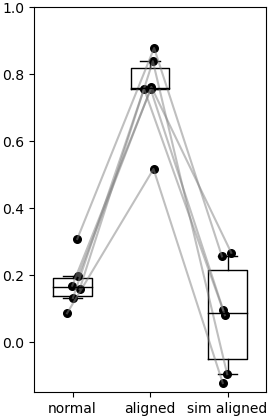

condition,normal,aligned,sim aligned
animal,,,
170,0.1583,0.8390,-0.0959
51004,0.0859,0.5168,-0.1224
51007,0.1974,0.7620,0.2667
63,0.1679,0.7552,0.0958
64,0.3079,0.8782,0.2560
65,0.1317,0.7567,0.0804


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,1.583684,2,0.791842,114.081487,1.305055e-07,0.865922,0.750048
1,Error,0.069410,10,0.006941,NaN,NaN,NaN,NaN


condition,normal,aligned,sim aligned
animal,,,
170,0.1583,0.8390,-0.0959
51004,0.0859,0.5168,-0.1224
51007,0.1974,0.7620,0.2667
63,0.1679,0.7552,0.0958
64,0.3079,0.8782,0.2560
65,0.1317,0.7567,0.0804


,Timepoint 1,Timepoint 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Diff,SD Diff,Normal Dist.,Normality p-value
0,normal,aligned,t-test,-16.9542,1.3058e-05,3.9173e-05,***,-6.9215,Cohen's d,-0.5765,0.0833,True,0.5351
1,normal,sim aligned,t-test,1.9690,0.1061,0.3182,,0.8038,Cohen's d,0.0947,0.1179,True,0.5621
2,aligned,sim aligned,t-test,11.3954,9.1089e-05,0.0003,***,4.6522,Cohen's d,0.6712,0.1443,True,0.1982


In [16]:
align_last=pop_correlation_arrays['config_1'][-1]
sim_last=pop_correlation_arrays['config_5'][-1]
normal_last=all_before_correlations[:,-1].T
print_large('\n' + '='*50)
print_large('Comparing normal, aligned and sim aligned pop corr to d0, last day')
print_large('='*50)

last_day_conditions = ['normal', 'aligned', 'sim aligned']

fig, ax = plt.subplots(figsize=(3, 5))
plots.boxplot_with_points_and_lines(np.vstack([[normal_last],[align_last],[sim_last]]).T, last_day_conditions,ax, '',ylim=[-0.15,1])

plt.show()
display(st.repeated_measures_anova_single_condition(
    np.vstack([normal_last,align_last,sim_last]).T,
    row_labels=animal_ids, col_labels=last_day_conditions, col_name='condition',
    title=f'Pop correlation to d0 on the last day (d{maps[-1]}): unaligned vs aligned vs sim aligned'))
display(st.post_hoc_timepoints(
    np.vstack([normal_last,align_last,sim_last]),
    row_labels=animal_ids, col_labels=last_day_conditions, col_name='condition',
    title=f'Post hoc, last day (d{maps[-1]}): unaligned vs aligned vs sim aligned'))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
c:\Users\oles\Documents\code\Sylte_Kilias_et_al\analysis_code\plots.py:479: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\oles\AppData\Local\Temp\ipykernel_26268\760259581.py:29: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


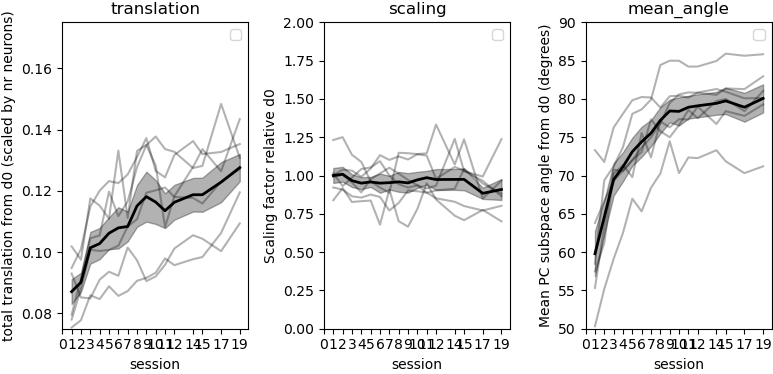

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.0754,0.0778,0.0859,0.0847,0.0889,0.0857,0.0873,0.0906,0.0916,0.0933,0.0979,0.0957,0.0977,0.0984,0.1062,0.1195
51004,0.0796,0.0913,0.1045,0.1055,0.1197,0.1117,0.1165,0.1277,0.1349,0.1377,0.1336,0.1327,0.1275,0.1282,0.1484,0.1308
51007,0.1018,0.0975,0.1175,0.1152,0.1109,0.1331,0.1112,0.1330,0.1350,0.1283,0.1082,0.1182,0.1278,0.1336,0.1264,0.1434
63,0.0930,0.0852,0.0849,0.0910,0.0936,0.0923,0.1015,0.0973,0.0905,0.0921,0.0959,0.1012,0.1055,0.1044,0.1003,0.1094
64,0.0948,0.1010,0.1149,0.1201,0.1232,0.1225,0.1253,0.1311,0.1372,0.1265,0.1244,0.1317,0.1362,0.1320,0.1327,0.1353
65,0.0780,0.0881,0.1008,0.1004,0.1007,0.1021,0.1083,0.1107,0.1194,0.1202,0.1211,0.1180,0.1177,0.1159,0.1230,0.1271


c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\pingouin\distribution.py:1006: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.product(eig) / (eig.sum() / d) ** d


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher
0,time,0.011205,15,0.000747,14.714172,1.207959e-16,0.000393,0.370873,0.160685,False,inf,0.0
1,Error,0.003808,75,0.000051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.9906,1.0055,0.9547,0.8900,0.9763,1.0141,1.0512,1.0126,0.9715,0.9366,0.9156,0.9341,1.2393,1.0280,0.9934,1.2372
51004,1.2319,1.2503,1.1354,1.0888,0.9615,0.9218,0.8879,1.1484,1.1456,1.1399,1.1453,1.3327,1.0720,1.2364,0.8496,0.9667
51007,0.8389,0.9177,0.8272,0.8324,0.8367,0.6791,0.9082,0.7019,0.6663,0.7820,0.9491,0.8440,0.7378,0.7084,0.7755,0.7011
63,0.9222,0.9075,0.8645,0.8559,0.8758,0.8600,0.7716,0.8213,0.9022,0.8974,0.8884,0.8514,0.8287,0.8009,0.7716,0.8024
64,1.0020,1.0377,1.0318,0.9919,1.0455,1.1332,1.1019,1.1248,1.1047,1.1390,1.1300,0.9785,1.0559,1.0318,0.9653,0.8649
65,1.0156,0.9313,0.9861,1.0423,1.0529,1.0935,1.0004,0.9429,0.9216,0.9354,0.8873,0.9030,0.9138,1.0438,0.9478,0.8813


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.084772,15,0.005651,0.638073,0.834129,0.046395,0.211607
1,Error,0.664279,75,0.008857,NaN,NaN,NaN,NaN


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,63.8076,66.6496,69.3046,70.6389,71.9861,73.0778,77.3319,75.7801,74.9964,76.5832,78.5582,77.4814,79.7294,79.9904,78.3925,81.0353
51004,58.4760,69.3674,71.2158,73.7067,78.0528,78.6389,79.9176,84.4246,84.9894,84.9848,84.2193,84.2305,84.9571,85.9108,85.6383,85.8333
51007,57.4839,61.1926,70.2065,71.3635,69.7963,75.5505,72.3712,77.0769,76.2880,77.3601,77.3147,78.9903,76.7255,78.4028,77.7888,79.2810
63,73.3112,71.7732,76.2635,78.0774,79.8254,80.2476,80.1863,78.8778,80.3532,80.4150,80.1799,80.8350,81.2920,80.9354,80.0805,80.1134
64,50.3150,55.2161,59.1178,62.5138,66.9789,65.3181,68.4066,70.2586,74.4623,70.3229,72.3619,72.2717,73.3038,71.8504,70.3115,71.2027
65,55.3296,63.3554,70.7534,70.5674,72.0301,73.6580,74.9853,76.8036,79.4729,80.5857,80.8537,80.8020,80.5362,81.3725,81.2798,82.9522


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,3194.168269,15,212.944551,36.789618,1.981006e-28,0.608949,0.117027
1,Error,434.112725,75,5.788170,NaN,NaN,NaN,NaN


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
c:\Users\oles\Documents\code\Sylte_Kilias_et_al\analysis_code\plots.py:479: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\oles\AppData\Local\Temp\ipykernel_26268\760259581.py:50: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


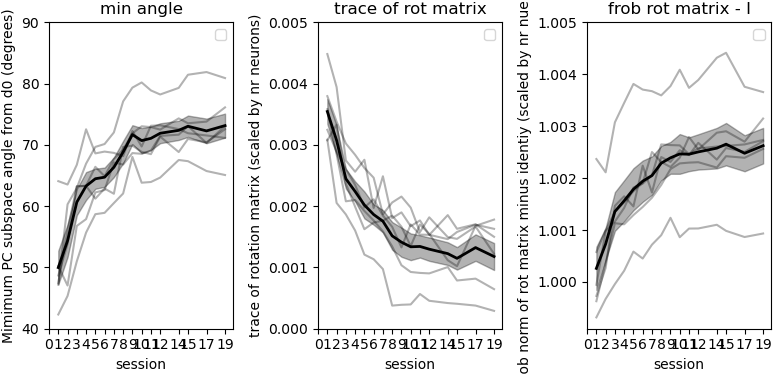

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,50.2026,47.0473,56.7777,57.8854,62.2326,62.6437,67.1242,66.7971,68.6648,68.5437,69.0670,71.4667,71.6667,73.0644,70.3141,73.0664
51004,47.1872,60.3002,62.9739,66.9420,69.6688,70.1441,72.0291,77.0971,79.3430,80.1890,78.8886,78.2249,79.3031,81.4479,81.8862,80.9045
51007,48.6908,53.8423,63.2380,63.3104,61.2256,62.8696,62.0257,69.6578,69.8873,68.8566,68.4888,71.3577,68.8317,70.9694,70.4143,72.5615
63,64.0816,63.5311,66.7508,72.5458,68.6116,68.9081,68.6934,68.1673,72.2729,69.7419,73.1247,73.1914,72.5763,71.9052,71.5378,71.1378
64,42.3213,45.3453,51.0088,55.6878,58.6886,58.9118,60.5049,62.0681,68.0358,63.8273,63.9456,64.6654,67.5362,67.3417,65.7342,65.0844
65,47.4152,56.1208,63.2279,63.3356,66.4218,64.8890,67.7063,69.2127,71.8868,73.0368,72.9027,72.4922,74.3259,73.5246,73.8004,76.1206


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,4350.744874,15,290.049658,34.305114,1.868479e-27,0.662,0.118578
1,Error,634.124832,75,8.454998,NaN,NaN,NaN,NaN


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.0038,0.0034,0.0030,0.0028,0.0026,0.0025,0.0019,0.0021,0.0022,0.0020,0.0016,0.0018,0.0015,0.0015,0.0017,0.0012
51004,0.0031,0.0021,0.0019,0.0016,0.0012,0.0011,0.0010,0.0004,0.0004,0.0004,0.0006,0.0005,0.0004,0.0004,0.0004,0.0003
51007,0.0045,0.0039,0.0027,0.0026,0.0028,0.0020,0.0025,0.0018,0.0019,0.0017,0.0018,0.0015,0.0019,0.0016,0.0017,0.0015
63,0.0031,0.0033,0.0024,0.0020,0.0016,0.0017,0.0018,0.0018,0.0017,0.0013,0.0017,0.0015,0.0011,0.0010,0.0017,0.0018
64,0.0032,0.0029,0.0026,0.0023,0.0020,0.0021,0.0018,0.0017,0.0013,0.0017,0.0015,0.0015,0.0015,0.0016,0.0017,0.0016
65,0.0036,0.0028,0.0021,0.0021,0.0019,0.0018,0.0016,0.0013,0.0010,0.0009,0.0009,0.0009,0.0010,0.0008,0.0008,0.0006


c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\pingouin\distribution.py:1006: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.product(eig) / (eig.sum() / d) ** d


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher
0,time,0.000046,15,3.042686e-06,51.266818,3.520982e-33,1.328496e-07,0.662197,0.183855,False,inf,0.0
1,Error,0.000004,75,5.935001e-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,1.0006,1.0010,1.0013,1.0015,1.0017,1.0019,1.0025,1.0023,1.0022,1.0024,1.0028,1.0026,1.0029,1.0029,1.0027,1.0031
51004,0.9999,1.0010,1.0012,1.0014,1.0018,1.0019,1.0021,1.0026,1.0026,1.0026,1.0025,1.0026,1.0026,1.0026,1.0026,1.0027
51007,0.9997,1.0003,1.0015,1.0016,1.0015,1.0022,1.0017,1.0024,1.0023,1.0025,1.0024,1.0027,1.0024,1.0026,1.0025,1.0027
63,1.0024,1.0021,1.0031,1.0034,1.0038,1.0037,1.0037,1.0036,1.0038,1.0041,1.0037,1.0039,1.0043,1.0044,1.0038,1.0037
64,0.9993,0.9997,1.0000,1.0002,1.0006,1.0005,1.0007,1.0009,1.0012,1.0009,1.0010,1.0010,1.0011,1.0010,1.0009,1.0009
65,0.9996,1.0004,1.0011,1.0011,1.0013,1.0014,1.0016,1.0019,1.0022,1.0023,1.0023,1.0023,1.0022,1.0024,1.0024,1.0026


c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\pingouin\distribution.py:1006: RuntimeWarning: divide by zero encountered in scalar divide
  W = np.product(eig) / (eig.sum() / d) ** d


,Source,SS,DF,MS,F,p-unc,p-GG-corr,ng2,eps,sphericity,W-spher,p-spher
0,time,0.000045,15,3.033292e-06,51.296616,3.452890e-33,1.352057e-07,0.370138,0.183567,False,inf,0.0
1,Error,0.000004,75,5.913240e-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
num_animals = len(results['config_1'])
num_days = len(next(iter(results['config_1'].values()))['translation_scale'])

animals = list(results['config_1'].keys())
day_cols = st.day_labels(maps)

translation_array = np.zeros((num_animals, num_days))
scale_factor_array = np.zeros((num_animals, num_days))
mean_angle_array = np.zeros((num_animals, num_days))
min_angle_array = np.zeros((num_animals, num_days))
princ_angle_array = np.zeros((num_animals, num_days))
trace_angle_array = np.zeros((num_animals, num_days))
frob_angle_array = np.zeros((num_animals, num_days))

for i, animal_data in enumerate(results['config_1'].values()):
    for j, ts in enumerate(animal_data['translation_scale']):
        translation_array[i, j] = ts['translation']
        scale_factor_array[i, j] = ts['scale_factor']
        mean_angle_array[i, j] = ts['mean_angle']
        min_angle_array[i, j] = ts['min_angle']
        princ_angle_array[i, j] = ts['principal_angle']
        trace_angle_array[i, j] = ts['trace']
        frob_angle_array[i, j] = ts['frobenius']

fig, ax = plt.subplots(1,3, figsize=(8, 4))
plots.plot_average_geometry([translation_array], maps,  colors=['k'], ax=ax[0], title='translation', ylim=[0.075, 0.175], labels=[''], ylabel='total translation from d0 (scaled by nr neurons)')
plots.plot_average_geometry([scale_factor_array], maps, colors=['k'],ax= ax[1], title='scaling', ylim=[0,2], labels=[''], ylabel='Scaling factor relative d0')
plots.plot_average_geometry([mean_angle_array],maps, colors=['k'], ax= ax[2], title='mean_angle', ylim=[50,90], labels=[''], ylabel='Mean PC subspace angle from d0 (degrees)')
fig.tight_layout()
fig.savefig(OUT / "fig4bc_translation_scaling_rotation.eps", format="eps")
plt.show()
print_large('Translation')
display(st.repeated_measures_anova_single_condition(
    translation_array, row_labels=animals, col_labels=day_cols,
    condition_label='translation', title='Total translation from d0'))
print_large('Scaling')
display(st.repeated_measures_anova_single_condition(
    scale_factor_array, row_labels=animals, col_labels=day_cols,
    condition_label='scale factor', title='Scaling factor relative to d0'))
print_large('rotation ')
display(st.repeated_measures_anova_single_condition(
    mean_angle_array, row_labels=animals, col_labels=day_cols,
    condition_label='mean angle (deg)', title='Mean PC subspace angle from d0'))


fig, ax = plt.subplots(1,3, figsize=(8, 4))
plots.plot_average_geometry([min_angle_array], maps,  colors=['k'], ax=ax[0], title='min angle', ylim=[40, 90], labels=[''], ylabel='Mimimum PC subspace angle from d0 (degrees)')
plots.plot_average_geometry([trace_angle_array], maps, colors=['k'],ax= ax[1], title='trace of rot matrix', ylim=[0,0.005], labels=[''], ylabel='trace of rotation matrix (scaled by nr neurons)')
plots.plot_average_geometry([frob_angle_array],maps, colors=['k'], ax= ax[2], title='frob rot matrix - I', ylim=[0.9991,1.005], labels=[''], ylabel='Frob norm of rot matrix minus identiy (scaled by nr nuerons)')
fig.tight_layout()
fig.savefig(OUT / "fig4bc_min_angle_trace_frobenius.eps", format="eps")
plt.show()
print_large('min angle')
display(st.repeated_measures_anova_single_condition(
    min_angle_array, row_labels=animals, col_labels=day_cols,
    condition_label='min angle (deg)', title='Minimum PC subspace angle from d0'))
print_large('trace of rot matrix')
display(st.repeated_measures_anova_single_condition(
    trace_angle_array, row_labels=animals, col_labels=day_cols,
    condition_label='trace(R)', title='Trace of the rotation matrix'))
print_large('frob rot matrix - I ')
display(st.repeated_measures_anova_single_condition(
    frob_angle_array, row_labels=animals, col_labels=day_cols,
    condition_label='Frobenius(R - I)', title='Frobenius norm of the rotation matrix minus identity'))




In [18]:
x1=translation_array
x2=scale_factor_array
x3=mean_angle_array
print(np.shape(all_before_correlations))

(6, 16)


,animal,day,translation,scaling,rotation,pop corr to d0
0,170,d1,0.0754,0.9906,63.8076,0.4368
1,170,d2,0.0778,1.0055,66.6496,0.4091
2,170,d3,0.0859,0.9547,69.3046,0.3407
3,170,d4,0.0847,0.8900,70.6389,0.3476
4,170,d5,0.0889,0.9763,71.9861,0.3045
5,170,d6,0.0857,1.0141,73.0778,0.2873
6,170,d7,0.0873,1.0512,77.3319,0.2443
7,170,d8,0.0906,1.0126,75.7801,0.2588
8,170,d9,0.0916,0.9715,74.9964,0.2597
9,170,d10,0.0933,0.9366,76.5832,0.2472


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.0754,0.0778,0.0859,0.0847,0.0889,0.0857,0.0873,0.0906,0.0916,0.0933,0.0979,0.0957,0.0977,0.0984,0.1062,0.1195
51004,0.0796,0.0913,0.1045,0.1055,0.1197,0.1117,0.1165,0.1277,0.1349,0.1377,0.1336,0.1327,0.1275,0.1282,0.1484,0.1308
51007,0.1018,0.0975,0.1175,0.1152,0.1109,0.1331,0.1112,0.1330,0.1350,0.1283,0.1082,0.1182,0.1278,0.1336,0.1264,0.1434
63,0.0930,0.0852,0.0849,0.0910,0.0936,0.0923,0.1015,0.0973,0.0905,0.0921,0.0959,0.1012,0.1055,0.1044,0.1003,0.1094
64,0.0948,0.1010,0.1149,0.1201,0.1232,0.1225,0.1253,0.1311,0.1372,0.1265,0.1244,0.1317,0.1362,0.1320,0.1327,0.1353
65,0.0780,0.0881,0.1008,0.1004,0.1007,0.1021,0.1083,0.1107,0.1194,0.1202,0.1211,0.1180,0.1177,0.1159,0.1230,0.1271


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.9906,1.0055,0.9547,0.8900,0.9763,1.0141,1.0512,1.0126,0.9715,0.9366,0.9156,0.9341,1.2393,1.0280,0.9934,1.2372
51004,1.2319,1.2503,1.1354,1.0888,0.9615,0.9218,0.8879,1.1484,1.1456,1.1399,1.1453,1.3327,1.0720,1.2364,0.8496,0.9667
51007,0.8389,0.9177,0.8272,0.8324,0.8367,0.6791,0.9082,0.7019,0.6663,0.7820,0.9491,0.8440,0.7378,0.7084,0.7755,0.7011
63,0.9222,0.9075,0.8645,0.8559,0.8758,0.8600,0.7716,0.8213,0.9022,0.8974,0.8884,0.8514,0.8287,0.8009,0.7716,0.8024
64,1.0020,1.0377,1.0318,0.9919,1.0455,1.1332,1.1019,1.1248,1.1047,1.1390,1.1300,0.9785,1.0559,1.0318,0.9653,0.8649
65,1.0156,0.9313,0.9861,1.0423,1.0529,1.0935,1.0004,0.9429,0.9216,0.9354,0.8873,0.9030,0.9138,1.0438,0.9478,0.8813


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,63.8076,66.6496,69.3046,70.6389,71.9861,73.0778,77.3319,75.7801,74.9964,76.5832,78.5582,77.4814,79.7294,79.9904,78.3925,81.0353
51004,58.4760,69.3674,71.2158,73.7067,78.0528,78.6389,79.9176,84.4246,84.9894,84.9848,84.2193,84.2305,84.9571,85.9108,85.6383,85.8333
51007,57.4839,61.1926,70.2065,71.3635,69.7963,75.5505,72.3712,77.0769,76.2880,77.3601,77.3147,78.9903,76.7255,78.4028,77.7888,79.2810
63,73.3112,71.7732,76.2635,78.0774,79.8254,80.2476,80.1863,78.8778,80.3532,80.4150,80.1799,80.8350,81.2920,80.9354,80.0805,80.1134
64,50.3150,55.2161,59.1178,62.5138,66.9789,65.3181,68.4066,70.2586,74.4623,70.3229,72.3619,72.2717,73.3038,71.8504,70.3115,71.2027
65,55.3296,63.3554,70.7534,70.5674,72.0301,73.6580,74.9853,76.8036,79.4729,80.5857,80.8537,80.8020,80.5362,81.3725,81.2798,82.9522


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.4368,0.4091,0.3407,0.3476,0.3045,0.2873,0.2443,0.2588,0.2597,0.2472,0.2089,0.2117,0.2036,0.2036,0.2022,0.1583
51004,0.4970,0.3616,0.3081,0.2817,0.2163,0.2270,0.1807,0.0856,0.0733,0.0628,0.1020,0.0942,0.0915,0.0948,0.0332,0.0859
51007,0.5079,0.4503,0.3007,0.2681,0.3054,0.2140,0.3087,0.2058,0.2172,0.1955,0.2404,0.1911,0.2217,0.2196,0.2240,0.1974
63,0.3003,0.3285,0.2429,0.2083,0.1876,0.1878,0.1750,0.1791,0.1965,0.1858,0.1804,0.1772,0.1450,0.1354,0.1693,0.1679
64,0.6280,0.5408,0.5092,0.4698,0.4063,0.4116,0.3669,0.3299,0.2690,0.3356,0.3191,0.3105,0.2844,0.3004,0.3158,0.3079
65,0.5370,0.4634,0.3678,0.3451,0.2958,0.2956,0.2580,0.2299,0.1858,0.1746,0.1790,0.1845,0.1703,0.1709,0.1552,0.1317


        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: y_std  
No. Observations: 96      Method:             REML   
No. Groups:       6       Scale:              0.0155 
Min. group size:  16      Log-Likelihood:     44.9029
Max. group size:  16      Converged:          Yes    
Mean group size:  16.0                               
-----------------------------------------------------
          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------
Intercept  0.000    0.073   0.000 1.000 -0.143  0.143
x1_std    -0.178    0.049  -3.644 0.000 -0.274 -0.082
x2_std     0.006    0.021   0.264 0.792 -0.036  0.047
x3_std    -0.846    0.040 -20.926 0.000 -0.925 -0.767
Group Var  0.031    0.224                            



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


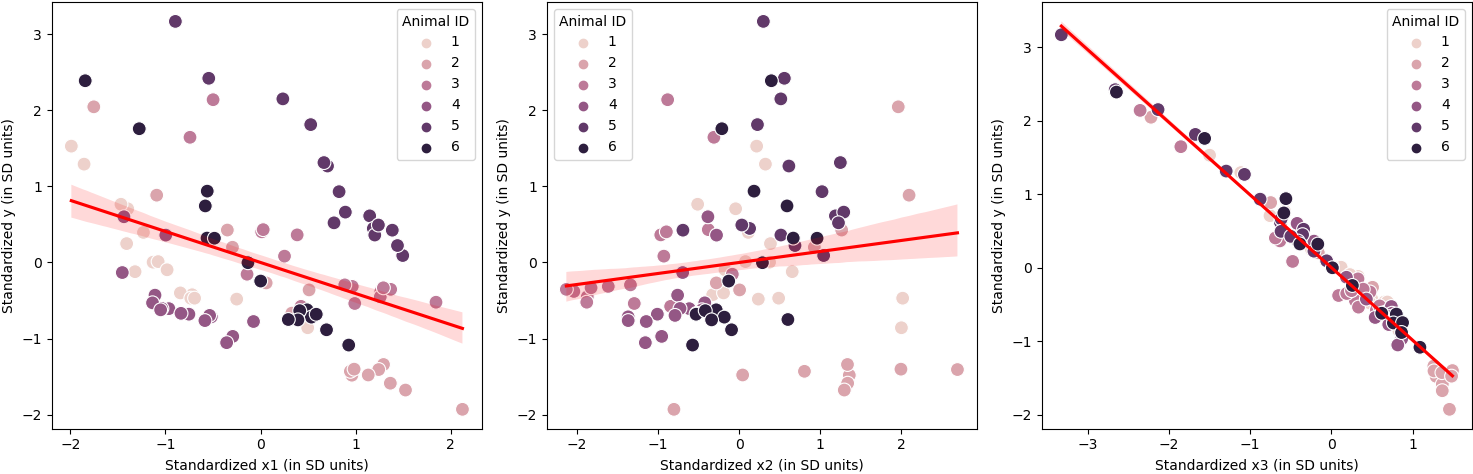

Intercept    1.000000e+00
x1_std       2.685667e-04
x2_std       7.920350e-01
x3_std       3.122383e-97
Group Var    2.659104e-01
dtype: float64


In [21]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
def run_analysis(x1, x2, x3, y, animal_id_codes, row_labels=None, obs_labels=None,
                 var_names=None, title=None, standardize=True):
    data_dict = {
        'x1': x1,
        'x2': x2,
        'x3': x3,
        'y': y,
        'animal_id': animal_id_codes
    }
    
    results_ml, data, prefix = st.fit_mixed_model(
        data_dict, standardize=standardize,
        row_labels=row_labels, obs_labels=obs_labels, col_name='day',
        var_names=var_names, title=title)
    print(results_ml.summary())


    fig_scatter = plots.plot_scatter(data, prefix)
    fig_scatter.savefig(OUT / "fig4bc_mixed_model_scatter.eps", format="eps")
    plt.figure(fig_scatter.number)
    plt.show()
    
    return results_ml, data, (_, fig_scatter)

results_ml, data, fig = run_analysis(
    translation_array, scale_factor_array, mean_angle_array, all_before_correlations,
    np.repeat([1, 2, 3, 4, 5, 6], 16),
    row_labels=animals, obs_labels=st.day_labels(maps),
    var_names=['translation', 'scaling', 'rotation', 'pop corr to d0'],
    title='Mixed model: translation / scaling / rotation vs pop correlation to d0')
print(results_ml.pvalues)
print_large('x1 = Translation, x2 = Scaling, x3 = Rotation, y = pop vector correlation to d0. All 4 standardized to compare on a common scale. Linear mixed models to account for differences across animals')

Computing real data correlations...
Computing rotational drift correlations...


C:\Users\oles\AppData\Local\Temp\ipykernel_26268\2113128526.py:90: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


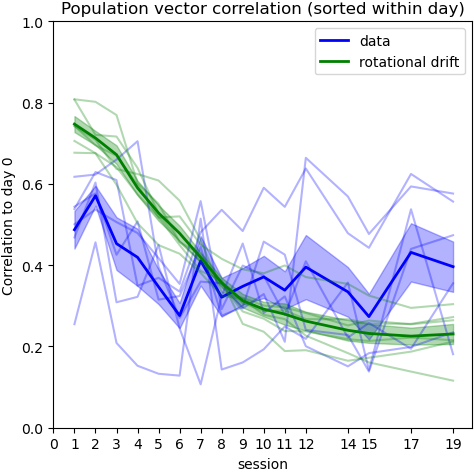

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.5006,0.5368,0.5060,0.4791,0.4172,0.3539,0.5576,0.2920,0.3991,0.3739,0.2775,0.4095,0.2218,0.2577,0.1943,0.3554
51004,0.5438,0.5765,0.4256,0.5077,0.3152,0.3241,0.4446,0.2757,0.2969,0.4580,0.4259,0.2407,0.2282,0.1383,0.4400,0.4737
51007,0.2548,0.4562,0.2086,0.1524,0.1328,0.1282,0.5144,0.1432,0.1607,0.1929,0.2491,0.2187,0.3571,0.1414,0.5375,0.1809
63,0.4682,0.6032,0.3087,0.3221,0.4500,0.2444,0.1068,0.3240,0.4533,0.2823,0.3232,0.2005,0.1510,0.1835,0.1988,0.2347
64,0.6175,0.6230,0.6598,0.7050,0.3958,0.2704,0.3595,0.3555,0.2934,0.3290,0.2115,0.6641,0.5690,0.4768,0.5938,0.5762
65,0.5382,0.6292,0.6094,0.3494,0.3688,0.3350,0.4809,0.5362,0.4840,0.5905,0.5435,0.6379,0.4786,0.4427,0.6244,0.5565


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.8075,0.7206,0.7165,0.6393,0.5267,0.4573,0.4264,0.3543,0.3071,0.2871,0.2886,0.2672,0.2668,0.2563,0.2555,0.2723
51004,0.7057,0.6754,0.6414,0.5742,0.5185,0.4494,0.3859,0.3629,0.2555,0.2362,0.1887,0.1908,0.1648,0.1722,0.1872,0.2121
51007,0.7422,0.7087,0.6366,0.6242,0.6082,0.5586,0.4618,0.3337,0.3194,0.3006,0.2960,0.2825,0.2517,0.2637,0.2544,0.2644
63,0.6767,0.6755,0.5979,0.5031,0.4494,0.4281,0.3810,0.3244,0.3171,0.2779,0.2673,0.2265,0.1836,0.1608,0.1382,0.1158
64,0.8081,0.8019,0.7694,0.6019,0.5507,0.4573,0.4092,0.3512,0.2861,0.2683,0.2379,0.2371,0.2179,0.2135,0.2218,0.2153
65,0.7430,0.6950,0.6693,0.5975,0.5172,0.5201,0.4504,0.4156,0.3900,0.3801,0.3993,0.3707,0.3539,0.3252,0.2948,0.3041


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,2.625792,15,75,0.175053,20.491892,1.254197e-20,0.000002,0.564465,0.249958
1,condition,0.030956,1,5,0.030956,0.480204,5.191930e-01,0.519193,0.015049,1.000000
2,time * condition,1.017392,15,75,0.067826,11.158515,1.288518e-13,0.000165,0.334292,0.232791


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1,data,rotational drift,t-test,-5.2344,0.0034,0.0539,,-2.1369,Cohen's d,0.4872,0.7472,-0.2600,0.1217,6,True,0.0503
1,d2,data,rotational drift,t-test,-4.6634,0.0055,0.0882,,-1.9038,Cohen's d,0.5708,0.7129,-0.1421,0.0746,6,True,0.3805
2,d3,data,rotational drift,t-test,-4.0873,0.0095,0.1515,,-1.6686,Cohen's d,0.4530,0.6718,-0.2188,0.1312,6,True,0.8330
3,d4,data,rotational drift,t-test,-2.1881,0.0803,1.0000,,-0.8933,Cohen's d,0.4193,0.5900,-0.1707,0.1911,6,True,0.9351
4,d5,data,rotational drift,t-test,-2.7940,0.0383,0.6122,,-1.1407,Cohen's d,0.3466,0.5284,-0.1818,0.1594,6,True,0.2379
5,d6,data,rotational drift,wilcoxon,0.0000,0.0312,0.5000,,0.8987,r,0.2760,0.4785,-0.2025,0.1172,6,False,0.0224
6,d7,data,rotational drift,t-test,-0.1461,0.8896,1.0000,,-0.0596,Cohen's d,0.4106,0.4191,-0.0085,0.1425,6,True,0.1442
7,d8,data,rotational drift,t-test,-0.8428,0.4378,1.0000,,-0.3441,Cohen's d,0.3211,0.3570,-0.0359,0.1045,6,True,0.9459
8,d9,data,rotational drift,t-test,0.8239,0.4475,1.0000,,0.3364,Cohen's d,0.3479,0.3125,0.0354,0.1052,6,True,0.1977
9,d10,data,rotational drift,t-test,1.5525,0.1813,1.0000,,0.6338,Cohen's d,0.3711,0.2917,0.0794,0.1253,6,True,0.6803


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.5006,0.5368,0.5060,0.4791,0.4172,0.3539,0.5576,0.2920,0.3991,0.3739,0.2775,0.4095,0.2218,0.2577,0.1943,0.3554
51004,0.5438,0.5765,0.4256,0.5077,0.3152,0.3241,0.4446,0.2757,0.2969,0.4580,0.4259,0.2407,0.2282,0.1383,0.4400,0.4737
51007,0.2548,0.4562,0.2086,0.1524,0.1328,0.1282,0.5144,0.1432,0.1607,0.1929,0.2491,0.2187,0.3571,0.1414,0.5375,0.1809
63,0.4682,0.6032,0.3087,0.3221,0.4500,0.2444,0.1068,0.3240,0.4533,0.2823,0.3232,0.2005,0.1510,0.1835,0.1988,0.2347
64,0.6175,0.6230,0.6598,0.7050,0.3958,0.2704,0.3595,0.3555,0.2934,0.3290,0.2115,0.6641,0.5690,0.4768,0.5938,0.5762
65,0.5382,0.6292,0.6094,0.3494,0.3688,0.3350,0.4809,0.5362,0.4840,0.5905,0.5435,0.6379,0.4786,0.4427,0.6244,0.5565


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.540060,15,0.036004,2.734371,0.002155,0.232005,0.245242
1,Error,0.987539,75,0.013167,NaN,NaN,NaN,NaN


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.8075,0.7206,0.7165,0.6393,0.5267,0.4573,0.4264,0.3543,0.3071,0.2871,0.2886,0.2672,0.2668,0.2563,0.2555,0.2723
51004,0.7057,0.6754,0.6414,0.5742,0.5185,0.4494,0.3859,0.3629,0.2555,0.2362,0.1887,0.1908,0.1648,0.1722,0.1872,0.2121
51007,0.7422,0.7087,0.6366,0.6242,0.6082,0.5586,0.4618,0.3337,0.3194,0.3006,0.2960,0.2825,0.2517,0.2637,0.2544,0.2644
63,0.6767,0.6755,0.5979,0.5031,0.4494,0.4281,0.3810,0.3244,0.3171,0.2779,0.2673,0.2265,0.1836,0.1608,0.1382,0.1158
64,0.8081,0.8019,0.7694,0.6019,0.5507,0.4573,0.4092,0.3512,0.2861,0.2683,0.2379,0.2371,0.2179,0.2135,0.2218,0.2153
65,0.7430,0.6950,0.6693,0.5975,0.5172,0.5201,0.4504,0.4156,0.3900,0.3801,0.3993,0.3707,0.3539,0.3252,0.2948,0.3041


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,3.103124,15,0.206875,142.302742,1.081017e-48,0.928684,0.165776
1,Error,0.109032,75,0.001454,NaN,NaN,NaN,NaN


In [20]:
reference = '0'
maps = [str(i) for i in np.arange(1, 13)] + ['14', '15', '17', '19']
MASTER_SEED = 42 


def sort_with_tiebreak(hist):
    argmax_values = np.argmax(hist, axis=1)  
    max_values = np.max(hist, axis=1)        
    
    # handle zero neurons
    zero_neurons = max_values == 0
    argmax_values[zero_neurons] = -1
    max_values[zero_neurons] = -1
    
    sort_indices = np.lexsort((-max_values, argmax_values))
    
    return hist[sort_indices]


# =================== REAL DATA ===================
def get_real_correlation_own_reference(datapaths, reference, maps):
    all_corr = []
    for datapath in datapaths:
        hist_sorts = analysis.sort_maps_from_reference_AK(
            datapath, 'Context1', reference=reference, maps=maps, 
            reference_type='no_reference', hist='hist', transients=False
        )
    
        sorted_maps = [sort_with_tiebreak(hist) for hist in hist_sorts]
        ref_map = sorted_maps[0]
        corr_future = [
            pop.ManifoldAnalysis.population_correlation(sorted_maps[day], ref_map)
            for day in range(1, len(sorted_maps))
        ]
        
        all_corr.append(corr_future)
    
    return np.vstack(all_corr)


# =================== SIMULATED DATA ===================
def get_simulated_correlation_own_reference(datapath, reference, maps, animal_seed):
    simu_drift = analysis.simulate_drift(
        datapath, session='0', Context='Context1', days=len(maps)+1, 
        drift_type='rotational', dim_red=False, standardize='stand', 
        odd_even=False, global_seed=animal_seed, 
        active_days=[reference]+maps, remove_day_inactive=True
    )
    
    sorted_maps = [sort_with_tiebreak(day_map) for day_map in simu_drift['maps']]
    manifold_reference = sorted_maps[0]
    correlations = [
        pop.ManifoldAnalysis.population_correlation(sorted_maps[day], manifold_reference)
        for day in range(1, len(sorted_maps))
    ]
    
    return np.array(correlations)


def get_all_simulated_correlations(datapaths, reference, maps, master_seed=42):
    sim_corr_list = []
    for animal_idx, datapath in enumerate(datapaths):
        animal_seed = master_seed + animal_idx
        sim_corr_list.append(
            get_simulated_correlation_own_reference(datapath, reference, maps, animal_seed)
        )
    return np.vstack(sim_corr_list)


# =================== ANALYSIS AND PLOTTING ===================
print("Computing real data correlations...")
corr_real = get_real_correlation_own_reference(datapaths, reference, maps)

print("Computing rotational drift correlations...")
corr_rotational = get_all_simulated_correlations(datapaths, reference, maps, master_seed=MASTER_SEED)

x_labels_corr = maps  
fig, ax = plt.subplots(figsize=(5, 5))
plots.plot_average_geometry(
    [corr_real, corr_rotational], 
    x_labels_corr,
    colors=['b', 'g'], 
    labels=['data', 'rotational drift'],
    plot_individual=True, 
    ylim=[0, 1], 
    ax=ax
)
ax.set_title('Population vector correlation (sorted within day)')
ax.set_ylabel('Correlation to day 0')
fig.tight_layout()
fig.savefig(OUT / "permutation_test.eps", format="eps")
plt.show()

animal_ids = st.animal_labels(datapaths)
day_cols = st.day_labels(maps)

print_large('\nTWO-WAY REPEATED ANOVA')
anova_results = st.repeated_measures_anova_general(
    [corr_real, corr_rotational],
    row_labels=animal_ids, col_labels=day_cols,
    condition_labels=['data', 'rotational drift'],
    title='Pop correlation to d0 (sorted within day): data vs rotational drift')
display(anova_results[0])
display(anova_results[1])

print_large('\nData:')
display(st.repeated_measures_anova_single_condition(
    corr_real, row_labels=animal_ids, col_labels=day_cols,
    condition_label='data',
    title='Pop correlation to d0 (sorted within day): data'))

print_large('\nRotational Drift:')
display(st.repeated_measures_anova_single_condition(
    corr_rotational, row_labels=animal_ids, col_labels=day_cols,
    condition_label='rotational drift',
    title='Pop correlation to d0 (sorted within day): rotational drift'))